## Imports & Logging Setup
`logging.basicConfig` runs **before** fiona suppressors.

In [1]:
import json, logging, warnings, argparse, math, dataclasses
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from datetime import datetime, timezone
from typing import Optional, List, Dict, Tuple
from shapely.geometry import Point, Polygon, MultiPolygon, GeometryCollection
from shapely.ops import unary_union
from shapely.validation import make_valid
from shapely.affinity import scale

warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s  %(levelname)-7s  %(message)s',
                    datefmt='%H:%M:%S')

logging.getLogger('fiona').setLevel(logging.ERROR)
logging.getLogger('fiona.ogrext').setLevel(logging.ERROR)
logging.getLogger('pyogrio').setLevel(logging.ERROR)
logging.getLogger('pyogrio._io').setLevel(logging.ERROR)
log = logging.getLogger(__name__)

try:
    _SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    _SCRIPT_DIR = Path().resolve()   

## Section 1 — FBFM40 Fuel Model Table
Scott & Burgan 2005, 22 fuel models.

In [2]:
FBFM40 = {
    101: dict(w0_1h=0.045,w0_10h=0.000,w0_100h=0.000,w0_lh=0.112,w0_lw=0.000,
              delta=0.30,mx=0.15,sav_d=11483,sav_lh=4921,rho_p=513,heat=18622),
    102: dict(w0_1h=0.045,w0_10h=0.000,w0_100h=0.000,w0_lh=0.224,w0_lw=0.000,
              delta=0.30,mx=0.15,sav_d=11483,sav_lh=4921,rho_p=513,heat=18622),
    103: dict(w0_1h=0.134,w0_10h=0.000,w0_100h=0.000,w0_lh=0.337,w0_lw=0.000,
              delta=0.61,mx=0.25,sav_d=11483,sav_lh=4921,rho_p=513,heat=18622),
    104: dict(w0_1h=0.269,w0_10h=0.000,w0_100h=0.000,w0_lh=0.673,w0_lw=0.000,
              delta=0.91,mx=0.25,sav_d=11483,sav_lh=4921,rho_p=513,heat=18622),
    121: dict(w0_1h=0.179,w0_10h=0.000,w0_100h=0.000,w0_lh=0.448,w0_lw=0.224,
              delta=0.61,mx=0.15,sav_d=9843, sav_lh=4921,rho_p=513,heat=18622),
    122: dict(w0_1h=0.359,w0_10h=0.179,w0_100h=0.000,w0_lh=0.269,w0_lw=0.448,
              delta=0.91,mx=0.15,sav_d=9843, sav_lh=4921,rho_p=513,heat=18622),
    141: dict(w0_1h=0.269,w0_10h=0.134,w0_100h=0.000,w0_lh=0.000,w0_lw=0.448,
              delta=0.61,mx=0.15,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    142: dict(w0_1h=1.123,w0_10h=0.449,w0_100h=0.134,w0_lh=0.000,w0_lw=1.123,
              delta=1.22,mx=0.30,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    143: dict(w0_1h=0.673,w0_10h=0.359,w0_100h=0.134,w0_lh=0.000,w0_lw=0.673,
              delta=1.22,mx=0.40,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    144: dict(w0_1h=0.673,w0_10h=0.359,w0_100h=0.134,w0_lh=0.000,w0_lw=0.897,
              delta=1.83,mx=0.40,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    161: dict(w0_1h=0.179,w0_10h=0.179,w0_100h=0.134,w0_lh=0.224,w0_lw=0.090,
              delta=0.30,mx=0.20,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    162: dict(w0_1h=0.718,w0_10h=0.359,w0_100h=0.134,w0_lh=0.224,w0_lw=0.224,
              delta=0.30,mx=0.30,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    163: dict(w0_1h=0.359,w0_10h=0.269,w0_100h=0.134,w0_lh=0.134,w0_lw=0.134,
              delta=0.30,mx=0.30,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    181: dict(w0_1h=0.269,w0_10h=0.359,w0_100h=0.718,w0_lh=0.000,w0_lw=0.000,
              delta=0.30,mx=0.20,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    182: dict(w0_1h=0.449,w0_10h=0.718,w0_100h=1.123,w0_lh=0.000,w0_lw=0.000,
              delta=0.30,mx=0.25,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    183: dict(w0_1h=0.269,w0_10h=0.449,w0_100h=0.718,w0_lh=0.000,w0_lw=0.000,
              delta=0.30,mx=0.20,sav_d=6562, sav_lh=4921,rho_p=513,heat=18622),
    201: dict(w0_1h=0.718,w0_10h=1.797,w0_100h=2.245,w0_lh=0.000,w0_lw=0.000,
              delta=0.91,mx=0.25,sav_d=4921, sav_lh=4921,rho_p=513,heat=18622),
    202: dict(w0_1h=1.797,w0_10h=3.594,w0_100h=4.492,w0_lh=0.000,w0_lw=0.000,
              delta=0.91,mx=0.25,sav_d=4921, sav_lh=4921,rho_p=513,heat=18622),
    91:  dict(w0_1h=0.0,w0_10h=0.0,w0_100h=0.0,w0_lh=0.0,w0_lw=0.0,
              delta=0.0,mx=0.99,sav_d=1.0,sav_lh=1.0,rho_p=513,heat=18622),
    92:  dict(w0_1h=0.0,w0_10h=0.0,w0_100h=0.0,w0_lh=0.0,w0_lw=0.0,
              delta=0.0,mx=0.99,sav_d=1.0,sav_lh=1.0,rho_p=513,heat=18622),
    98:  dict(w0_1h=0.0,w0_10h=0.0,w0_100h=0.0,w0_lh=0.0,w0_lw=0.0,
              delta=0.0,mx=0.99,sav_d=1.0,sav_lh=1.0,rho_p=513,heat=18622),
    99:  dict(w0_1h=0.0,w0_10h=0.0,w0_100h=0.0,w0_lh=0.0,w0_lw=0.0,
              delta=0.0,mx=0.99,sav_d=1.0,sav_lh=1.0,rho_p=513,heat=18622),
}
_DEFAULT_FUEL = FBFM40[144]

def get_fuel(code):
    if code is None: return _DEFAULT_FUEL
    try:   c = int(round(float(code)))
    except: return _DEFAULT_FUEL
    return FBFM40.get(c, _DEFAULT_FUEL)

## Section 1B — Raster Fuel Override

In [3]:
_KG_M2_TO_LB_FT2 = 0.20482   # kg/m² → lb/ft²
_M2_M3_TO_FT2_FT3= 0.30480   # m²/m³ → ft²/ft³ (= 1/3.281)

def raster_fuel_dict(row, code=None) -> dict:

    base = dict(get_fuel(code))   

    def _rload(col):
        v = _safe(row, col, None)
        return None if (v is None or v <= 0) else v * _KG_M2_TO_LB_FT2

    w1   = _rload('fuel_load_1h_kg_m2')
    w10  = _rload('fuel_load_10h_kg_m2')
    w100 = _rload('fuel_load_100h_kg_m2')
    sav  = _safe(row, 'fuel_sav_m2_m3', None)

    if w1   is not None: base['w0_1h']   = w1
    if w10  is not None: base['w0_10h']  = w10
    if w100 is not None: base['w0_100h'] = w100
    if sav  is not None and sav > 0:
        base['sav_d'] = sav * _M2_M3_TO_FT2_FT3

    return base

## Section 1C — Per-Fuel Moisture Table

In [4]:
_DEFAULT_FUEL_MOISTURES: List[List] = [
    [0, 0.08, 0.10, 0.12, 0.60, 0.90],
]


@dataclasses.dataclass
class FuelMoistureTable:
    rows: List[List] = dataclasses.field(
        default_factory=lambda: list(_DEFAULT_FUEL_MOISTURES))

    @classmethod
    def from_farsite_list(cls, data: List[List]) -> 'FuelMoistureTable':
        normalised = []
        for row in data:
            code = int(row[0])
            vals = [v/100.0 if v > 1.5 else float(v) for v in row[1:]]
            normalised.append([code] + vals)
        return cls(rows=normalised)

    def get(self, fuel_code) -> Dict[str, float]:
        try: code = int(round(float(fuel_code))) if fuel_code else 0
        except: code = 0
        base = None; override = None
        for row in self.rows:
            if row[0] == 0:    base     = row
            if row[0] == code: override = row
        chosen = override if override is not None else base
        if chosen is None:
            return dict(m1h=0.08, m10h=0.10, m100h=0.12, mlh=0.60, mlw=0.90)
        return dict(m1h=chosen[1], m10h=chosen[2], m100h=chosen[3],
                    mlh=chosen[4],  mlw=chosen[5])

## Section 1D — Structure Risk Engine
Cohen (2000) susceptibility · building height multiplier · density multiplier.

In [5]:
_BLDG_WEIGHTS = {
    'woodRoof':         0.35,
    'woodSiding':       0.25,
    'combustableDeck':  0.20,
    'eaves':            0.15,
    'ventScreens_in':   0.05,  
}
_FIREBRAND_BUFFER_M = 500.0 


@dataclasses.dataclass
class StructureRiskResult:
    n_structures_at_risk:    int   = 0
    ignition_susceptibility: float = 0.0   
    ember_intrusion_risk:    float = 0.0  
    residential_exposure:    float = 0.0  
    structural_loss_index:   float = 0.0   
    spot_amplification:      float = 1.0  


class StructureRiskEngine:


    def __init__(self, row0):
 
        self._wood_roof    = _safe(row0, 'frac_wood_roof',        0.5)
        self._wood_siding  = _safe(row0, 'frac_wood_siding',      0.5)
        self._comb_deck    = _safe(row0, 'frac_combustable_deck', 0.3)
        self._eaves        = _safe(row0, 'frac_closed_eaves',     0.5)
        self._vent_screens = _safe(row0, 'avg_vent_screens_in',   0.5)
        for attr in ('_wood_roof','_wood_siding','_comb_deck',
                     '_eaves','_vent_screens'):
            v = getattr(self, attr)
            setattr(self, attr, max(0.0, min(1.0, float(v))))

        self._base_susceptibility = (
            self._wood_roof    * 0.35 +
            self._wood_siding  * 0.25 +
            self._comb_deck    * 0.20 +
            self._eaves        * 0.15 +
            (1.0 - self._vent_screens) * 0.05)  # invert: no screens = higher risk

        self._residential_frac = _safe(row0, 'frac_residential', 0.7)
        if self._residential_frac > 1.0:
            self._residential_frac = 0.7 


        avg_ht = max(1.0, _safe(row0, 'avg_building_height_m', 5.0))
        self._height_factor = min(1.30, 1.0 + 0.05 * max(0.0, avg_ht - 5.0) / 5.0)

        density = max(0.0, _safe(row0, 'building_density_per_km2', 0.0))
        self._density_factor = min(1.5, 1.0 + density / 500.0)

        log.info(f'  StructureRiskEngine: '
                 f'susceptibility={self._base_susceptibility:.3f}  '
                 f'height_factor={self._height_factor:.3f}  '
                 f'density_factor={self._density_factor:.3f}  '
                 f'residential={self._residential_frac:.2f}')

    def evaluate(self, area_km2: float, n_buildings_total: int,
                 spot_prob: float) -> StructureRiskResult:

        if n_buildings_total <= 0:
            return StructureRiskResult()

        sample_area_km2 = math.pi * 2.0**2   # ≈ 12.57 km²
        fire_plus_buffer_km2 = area_km2 + math.pi * (_FIREBRAND_BUFFER_M/1000)**2
        exposure_frac = min(1.0, fire_plus_buffer_km2 / sample_area_km2)
        n_at_risk = int(round(n_buildings_total * exposure_frac))

        susceptibility = self._base_susceptibility
        ember_risk     = 1.0 - self._vent_screens  # higher = more ember intrusion

        exposure_frac = min(1.0, exposure_frac * self._density_factor)
        n_at_risk     = int(round(n_buildings_total * exposure_frac))


        loss_idx = min(1.0, exposure_frac * susceptibility
                       * (1.0 + spot_prob) * self._height_factor)

        spot_amp = 1.0 + 0.5 * susceptibility * exposure_frac * self._height_factor

        return StructureRiskResult(
            n_structures_at_risk    = n_at_risk,
            ignition_susceptibility = round(susceptibility, 4),
            ember_intrusion_risk    = round(ember_risk, 4),
            residential_exposure    = round(self._residential_frac, 4),
            structural_loss_index   = round(loss_idx, 4),
            spot_amplification      = round(spot_amp, 4),
        )


_NULL_STRUCT = StructureRiskResult()

## Section 1E — Road Suppression Model

In [6]:
_ROAD_DENSITY_HIGH   = 2.0  
_ROAD_DENSITY_MEDIUM = 0.8
_ROAD_DENSITY_LOW    = 0.2   


_AUTO_SUPP_ONSET_HIGH   =  4.0   
_AUTO_SUPP_ONSET_MEDIUM = 12.0
_AUTO_SUPP_ONSET_LOW    = 30.0
_AUTO_SUPP_ONSET_NONE   = 48.0  


_AUTO_SUPP_DUR_HIGH   =  6.0
_AUTO_SUPP_DUR_MEDIUM = 12.0
_AUTO_SUPP_DUR_LOW    = 20.0
_AUTO_SUPP_DUR_NONE   = 24.0


_DEFAULT_ROAD_SEG_LEN_M = 150.0


def road_density_km_per_km2(road_count: float, area_km2: float,
                             seg_len_m: float = _DEFAULT_ROAD_SEG_LEN_M) -> float:

    if area_km2 <= 0 or road_count <= 0: return 0.0
    total_km = road_count * seg_len_m / 1000.0
    return total_km / area_km2


def auto_suppression_params(road_count: float,
                             seg_len_m: float = _DEFAULT_ROAD_SEG_LEN_M
                             ) -> Tuple[float, float]:

    density = road_density_km_per_km2(road_count, math.pi*4.0, seg_len_m)
    if density >= _ROAD_DENSITY_HIGH:
        return _AUTO_SUPP_ONSET_HIGH,   _AUTO_SUPP_DUR_HIGH
    elif density >= _ROAD_DENSITY_MEDIUM:
        onset = _AUTO_SUPP_ONSET_HIGH + \
                (_AUTO_SUPP_ONSET_MEDIUM - _AUTO_SUPP_ONSET_HIGH) * \
                (1.0 - (density - _ROAD_DENSITY_MEDIUM) /
                 (_ROAD_DENSITY_HIGH - _ROAD_DENSITY_MEDIUM))
        dur   = _AUTO_SUPP_DUR_HIGH + \
                (_AUTO_SUPP_DUR_MEDIUM - _AUTO_SUPP_DUR_HIGH) * \
                (1.0 - (density - _ROAD_DENSITY_MEDIUM) /
                 (_ROAD_DENSITY_HIGH - _ROAD_DENSITY_MEDIUM))
        return round(onset, 1), round(dur, 1)
    elif density >= _ROAD_DENSITY_LOW:
        onset = _AUTO_SUPP_ONSET_MEDIUM + \
                (_AUTO_SUPP_ONSET_LOW - _AUTO_SUPP_ONSET_MEDIUM) * \
                (1.0 - (density - _ROAD_DENSITY_LOW) /
                 (_ROAD_DENSITY_MEDIUM - _ROAD_DENSITY_LOW))
        dur   = _AUTO_SUPP_DUR_MEDIUM + \
                (_AUTO_SUPP_DUR_LOW - _AUTO_SUPP_DUR_MEDIUM) * \
                (1.0 - (density - _ROAD_DENSITY_LOW) /
                 (_ROAD_DENSITY_MEDIUM - _ROAD_DENSITY_LOW))
        return round(onset, 1), round(dur, 1)
    else:
        return _AUTO_SUPP_ONSET_NONE, _AUTO_SUPP_DUR_NONE



_ROAD_DISTANCE_MAX_DELAY_H = 8.0
_ROAD_DISTANCE_REF_M       = 2000.0


def road_distance_delay_h(nearest_road_m: float) -> float:

    if nearest_road_m <= 0: return 0.0
    scale = math.log(1 + _ROAD_DISTANCE_REF_M / 200.0)
    return min(_ROAD_DISTANCE_MAX_DELAY_H,
               math.log(1 + nearest_road_m / 200.0) / scale
               * _ROAD_DISTANCE_MAX_DELAY_H)

## Section 1F — WeatherRecord Dataclass
Validated per-timestep atmospheric state including `nearest_road_m`.

In [7]:
def _col_exists(row, col: str) -> bool:
    try: return col in row.keys()
    except: return False


@dataclasses.dataclass
class WeatherRecord:
    datetime_str:          str
    elapsed_hours:         float
    temp_f:                float = 65.0
    humidity_pct:          float = 35.0
    precipitation_mm:      float = 0.0
    wind_speed_mph:        float = 5.0
    wind_dir_deg:          float = 180.0
    cloud_cover_pct:       float = 0.0
    wind_meas_height_m:    float = 10.0
    elevation_m:           float = 0.0   
    station_elevation_m:   float = -1.0   
    weather_source:        str   = ''     
    building_count:           float = 0.0  
    road_count:               float = 0.0   
    total_road_length_m:      float = 0.0   
    road_density_m_per_km2:   float = 0.0   
    nearest_road_m:           float = 0.0    
    frac_paved:               float = 0.0   
    frac_high_capacity:       float = 0.0    
    fuel_moist_1h:         Optional[float] = None
    fuel_moist_10h:        Optional[float] = None
    fuel_moist_100h:       Optional[float] = None

    def __post_init__(self):
        self.temp_f             = float(self.temp_f)
        self.humidity_pct       = max(1.0, min(99.0, float(self.humidity_pct)))
        self.precipitation_mm   = max(0.0, float(self.precipitation_mm))
        self.wind_speed_mph     = max(0.0, float(self.wind_speed_mph))
        self.wind_dir_deg       = float(self.wind_dir_deg) % 360.0
        self.cloud_cover_pct    = max(0.0, min(100.0, float(self.cloud_cover_pct)))
        self.wind_meas_height_m = max(2.0, float(self.wind_meas_height_m))
        self.elevation_m        = max(0.0, float(self.elevation_m))
        # station_elevation_m: -1 = sentinel (use site elevation, no correction)
        self.station_elevation_m = float(self.station_elevation_m)
        # weather_source stays as string
        self.building_count          = max(0.0, float(self.building_count))
        self.road_count              = max(0.0, float(self.road_count))
        self.total_road_length_m     = max(0.0, float(self.total_road_length_m))
        self.road_density_m_per_km2  = max(0.0, float(self.road_density_m_per_km2))
        self.nearest_road_m          = max(0.0, float(self.nearest_road_m))
        self.frac_paved              = max(0.0, min(1.0, float(self.frac_paved)))
        self.frac_high_capacity      = max(0.0, min(1.0, float(self.frac_high_capacity)))

    @classmethod
    def from_row(cls, row) -> 'WeatherRecord':
        def _g(k, d): return _safe(row, k, d)
        def _opt(k):
            try:
                if _col_exists(row, k):
                    v = _safe(row, k, None)
                    if v is not None:
                        return v / 100.0 if v > 1.5 else v
            except Exception: pass
            return None
        return cls(
            datetime_str       = str(row['datetime']),
            elapsed_hours      = float(row['elapsed_hours']),
            temp_f             = _g('temp_f',            65.0),
            humidity_pct       = _g('humidity_pct',      35.0),
            precipitation_mm   = _g('precipitation_mm',   0.0),
            wind_speed_mph     = _g('wind_speed_mph',     5.0),
            wind_dir_deg       = _g('wind_dir_deg',     180.0),
            cloud_cover_pct    = _g('cloud_cover_pct',    0.0),
            wind_meas_height_m = _g('wind_meas_height_m',10.0),
            elevation_m          = _g('elevation_m',          0.0),
            station_elevation_m  = _g('station_elevation_m',  -1.0),
            weather_source       = str(row.get('weather_source', '') or ''),
            building_count           = _g('building_count',          0.0),
            road_count               = _g('road_count',               0.0),
            total_road_length_m      = _g('total_road_length_m',      0.0),
            road_density_m_per_km2   = _g('road_density_m_per_km2',   0.0),
            nearest_road_m           = _g('nearest_road_m',           0.0),
            frac_paved               = _g('frac_paved',               0.0),
            frac_high_capacity       = _g('frac_high_capacity',       0.0),
            fuel_moist_1h      = _opt('fuel_moist_1h'),
            fuel_moist_10h     = _opt('fuel_moist_10h'),
            fuel_moist_100h    = _opt('fuel_moist_100h'),
        )

## Sections 2–4 — ROS Caps · Spatial Sampler · Burnout Rate

In [8]:
ROS_CAP_SURFACE_M_MIN = 2.5
ROS_CAP_CROWN_ACTIVE  = 8.0
ROS_CAP_CROWN_PASSIVE = 4.0
MAX_AREA_INCREMENT_KM2= 5.0
MAX_STEP_MINUTES      = 30

class SpatialLandscapeSampler:
    LAYERS = {
        'fuel_model':       ['fbfm40_5070.tif'],
        'slope_pct':        ['slope_5070.tif'],
        'aspect_deg':       ['aspect_5070.tif'],
        'canopy_cover_pct': ['canopy_cover_5070.tif'],
        'canopy_height_m':  ['canopy_height_5070.tif'],
        'canopy_base_m':    ['canopy_base_height_5070.tif'],
        'canopy_density':   ['canopy_bulk_density_5070.tif'],
        'elevation_m':      ['elevation_5070.tif'],  

        'fuel_depth_m':     ['Forest_depth.tif', 'fuel_depth_5070.tif'],

        'fuel_load_1h_kg_m2':   ['Forest_rhof1.tif',   'fuel_load_1h_5070.tif'],
        'fuel_load_10h_kg_m2':  ['Forest_rhof10.tif',  'fuel_load_10h_5070.tif'],
        'fuel_load_100h_kg_m2': ['Forest_rhof100.tif', 'fuel_load_100h_5070.tif'],
        'fuel_sav_m2_m3':       ['Forest_SAV.tif',     'fuel_sav_5070.tif'],
    }

    def __init__(self, landscape_dir=None, proj_crs='EPSG:5070'):
        self._dir    = Path(landscape_dir) if landscape_dir else None
        self._cache  = {}
        self._loaded = False
        self._crs    = proj_crs

    def _try_load(self):
        if self._loaded: return
        self._loaded = True
        if self._dir is None or not self._dir.exists():
            log.info('  SpatialSampler: no landscape dir → using centroid values')
            return
        try:
            import rasterio
        except ImportError:
            log.warning('  SpatialSampler: rasterio not installed')
            return
        loaded = 0
        for feat, candidates in self.LAYERS.items():
            for name in candidates:
                p = self._dir / name
                if not p.exists(): continue
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        with rasterio.open(p) as src:
                            data = src.read(1).astype(float)
                            nd   = src.nodata; trans = src.transform
                    if nd is not None: data[data == nd] = np.nan
                    self._cache[feat] = (data, trans); loaded += 1; break
                except Exception as e:
                    log.debug(f'  SpatialSampler: {feat}: {e}')
        loaded_names = [k for k in self.LAYERS if k in self._cache]
        missing = [k for k in self.LAYERS if k not in self._cache]
        log.info(f'  SpatialSampler: loaded {loaded}/{len(self.LAYERS)} layers '
                 f'from {self._dir.name}')
        if missing:
            log.info(f'  SpatialSampler: missing layers (will use centroid CSV): '
                     f'{", ".join(missing)}')

    def sample(self, x_proj, y_proj, fallback: dict) -> dict:
        self._try_load()
        if not self._cache: return fallback.copy()
        result = fallback.copy()
        for feat, (data, trans) in self._cache.items():
            try:
                nrows, ncols = data.shape
                col_f = (x_proj - trans.c) / trans.a
                row_f = (y_proj - trans.f) / trans.e
                if col_f < -0.5 or col_f > ncols+0.5: continue
                if row_f < -0.5 or row_f > nrows+0.5: continue
                col = int(np.clip(round(col_f), 0, ncols-1))
                row = int(np.clip(round(row_f), 0, nrows-1))
                val = data[row, col]
                if not np.isnan(val): result[feat] = round(float(val), 4)
            except Exception: pass
        return result

    @property
    def enabled(self):
        self._try_load(); return len(self._cache) > 0

In [9]:
#  BURNOUT DECAY RATE
def burnout_rate(humidity_pct, wind_mph, moist_1h, base_k=0.15,
                 area_km2=None, peak_area_km2=None):
    hum_f  = max(0.0, (humidity_pct - 20.0) / 70.0) * 0.08
    wind_f = -min(0.05, wind_mph / 15.0 * 0.05)
    mf     = max(0.0, (moist_1h - 0.06) / 0.20) * 0.06
    kw     = max(0.10, min(0.60, base_k + hum_f + wind_f + mf))
    if area_km2 is not None and peak_area_km2 and peak_area_km2 > 0:
        frac  = max(1e-6, area_km2 / peak_area_km2)
        accel = (1.0 + 1.5*(0.20 - frac)/0.20) if frac < 0.20 else 1.0
        accel = min(accel, 4.0)
    else: accel = 1.0
    return max(0.10, min(0.60, kw * accel))


def fuel_spread_radius_m(ros_cap, total_days=7.0):
    return max(2000.0, min(30000.0, ros_cap * total_days * 24 * 60 * 0.40))

## Sections 5–6 — Fuel Moisture Dynamics + Lapse Correction

In [10]:
def equilibrium_moisture(temp_f, rh_pct):
    rh = max(0.5, min(99.5, rh_pct))
    T  = (temp_f - 32.0) * 5.0 / 9.0
    if rh < 10.0:   emc = 0.03229 + 0.281073*rh - 0.000578*T*rh
    elif rh <= 50.0: emc = 2.22749 + 0.160107*rh - 0.014784*T
    else:            emc = 21.0606 + 0.005565*(rh**2) - 0.00035*rh*T - 0.483199*rh
    return max(0.01, emc / 100.0)

def update_moisture_1h(m, emc, dt=30.0):
    return emc + (m - emc) * math.exp(-dt / 60.0)

def update_moisture_10h(m, emc, dt=30.0):
    return emc + (m - emc) * math.exp(-dt / 600.0)

def precip_wetting(m1h, m10h, m100h, precip_mm, dt_min=30.0):
    if precip_mm <= 0.0: return m1h, m10h, m100h
    return (min(0.35, m1h   + 0.025*min(precip_mm,10.0)),
            min(0.25, m10h  + 0.010*min(precip_mm,10.0)),
            min(0.20, m100h + 0.004*min(precip_mm,10.0)))



_LAPSE_RATE_C_PER_M  = 0.0065   # ICAO standard atmosphere, °C/m
_LAPSE_RATE_F_PER_FT = _LAPSE_RATE_C_PER_M * 1.8 / 0.3048  # °F/ft ≈ 0.003566

def lapse_corrected_temp_f(temp_f_station: float, elevation_m: float,
                            station_elev_m: float = -1.0,
                            weather_source: str = '') -> float:

    source_lower = weather_source.lower() if weather_source else ''
    if station_elev_m == -1.0:
        if 'open-meteo' in source_lower or 'openmeteo' in source_lower:
            effective_station_elev = elevation_m   # no correction
        else:
            effective_station_elev = 0.0        
    else:
        effective_station_elev = station_elev_m

    delta_m = elevation_m - effective_station_elev
    if abs(delta_m) < 1.0:
        return temp_f_station   
    delta_f = delta_m * _LAPSE_RATE_C_PER_M * 1.8   # °C/m → °F/m × Δm
    return temp_f_station - delta_f

## Sections 7–13 — Fire Physics

In [11]:

def diurnal_factor(hour_utc, cloud_cover_pct=0.0):
    angle = 2.0 * math.pi * (hour_utc - 3.0) / 24.0
    clear = 0.35 + 0.65 * (0.5 + 0.5 * math.sin(angle - math.pi / 2.0))
    cc    = max(0.0, min(1.0, cloud_cover_pct / 100.0))
    return clear * (1.0 - cc) + 0.625 * cc

def suppression_factor(elapsed_h, suppression_start_h, suppression_duration_h):
    if suppression_start_h is None: return 1.0
    if elapsed_h < suppression_start_h: return 1.0
    t    = elapsed_h - suppression_start_h
    frac = t / max(suppression_duration_h, 0.5)
    return max(0.0, 1.0 - frac)

_Z0_BASE  = 0.13
_Z_20FT   = 6.096


def _z0_at_elevation(elev_m: float) -> float:

    return _Z0_BASE * math.exp(-elev_m / 8500.0)


def wind_at_height(wind_meas, z_meas, z_target, elev_m=0.0):
    if abs(z_target - z_meas) < 0.1: return wind_meas
    z0 = _z0_at_elevation(elev_m)
    z_meas   = max(z_meas,   z0 * 1.01)
    z_target = max(z_target, z0 * 1.01)
    ratio = math.log(z_target / z0) / math.log(z_meas / z0)
    return max(0.0, min(wind_meas * ratio, wind_meas * 2.0))


def wind_adjustment_factor(cc, cht, fdepth):
    cover = max(0.0, min(1.0, cc/100.0 if cc > 1.5 else cc))
    H = max(0.1, cht if cht else 0.1)
    d = max(0.01, fdepth if fdepth else 0.3)
    if cover < 0.05:
        return max(0.3, min(1.0, 1.83 / math.log((20.0+0.36*d)/(0.13*d))))
    return max(0.05, min(0.9,
        (0.555/math.sqrt(cover*H))*math.log((20.0+0.36*H)/(0.13*H))))


def compute_wind_midflame(wind_10m_mph, meas_height_m, cc, cht, fdepth,
                           elev_m=0.0):
    """Full pipeline with elevation correction (J5)."""
    wind_20ft = wind_at_height(wind_10m_mph, meas_height_m, _Z_20FT, elev_m)
    waf       = wind_adjustment_factor(cc, cht, fdepth)
    return wind_20ft * waf, waf

In [12]:
#  ROTHERMEL (1972) FULL DEAD+LIVE
def rothermel_ros(fuel, wind_mf, slope_pct, m1h, m10h, m100h,
                  mlh=None, mlw=None):
    rho_p = fuel['rho_p'] * 0.0624
    if (fuel['w0_1h']+fuel['w0_10h']+fuel['w0_100h']
            +fuel['w0_lh']+fuel['w0_lw']) < 1e-6: return 0,0,0,0,0
    if fuel['sav_d'] < 2.0: return 0,0,0,0,0
    lb=lambda v:v*0.2048; ft=lambda v:v*3.2808; sv=lambda v:v*0.3048
    wd1=lb(fuel['w0_1h']);wd10=lb(fuel['w0_10h']);wd100=lb(fuel['w0_100h'])
    wlh=lb(fuel['w0_lh']);wlw=lb(fuel['w0_lw'])
    sd=sv(fuel['sav_d']);slh=sv(fuel['sav_lh'])
    sd10=sv(109.0);sd100=sv(30.0);slw=sv(492.1)
    dft=ft(max(fuel['delta'],0.01));mx=fuel['mx']
    if mlh is None: mlh=max(0.30,m1h*3.0)
    if mlw is None: mlw=max(0.60,m1h*4.0)
    fd=[(wd1,sd,m1h),(wd10,sd10,m10h),(wd100,sd100,m100h)]
    fl=[(wlh,slh,mlh),(wlw,slw,mlw)]
    def _wt(fs):
        ns=ds=wn=0.0
        for w,s,m in fs:
            if w<1e-9: continue
            ns+=w*s;ds+=w;wn+=w
        return (ns/ds if ds>0 else 1.0),wn
    sdead,wdead=_wt(fd);slive,wlive=_wt(fl)
    if wdead<1e-9: return 0,0,0,0,0
    sigma=(sdead*wdead+slive*wlive)/(wdead+wlive+1e-12)
    rhob=(wdead+wlive)/dft;beta=rhob/rho_p
    bop=max(3.348*sigma**-0.8189,1e-6)
    A=133.0*sigma**-0.7913;Gmax=(sigma**1.5)/(495.0+0.0594*sigma**1.5)
    rat=beta/bop;G=Gmax*(rat**A)*math.exp(A*(1.0-rat))
    nm=sum(w*m for w,s,m in fd if w>1e-9);dm=sum(w for w,s,m in fd if w>1e-9)
    Mf=nm/dm if dm>0 else m1h
    if Mf>=mx: return 0,0,0,0,0
    rM=Mf/mx;etaM=max(0.0,1.0-2.59*rM+5.11*rM**2-3.52*rM**3)
    etaS=min(1.0,0.174*0.01**-0.19);Ir=max(0.0,G*wdead*fuel['heat']*0.4299*etaM*etaS)
    xi=(math.exp((0.792+0.681*sigma**0.5)*(beta+0.1))/(192.0+0.2595*sigma))
    wfm=wind_mf*88.0;C=7.47*math.exp(-0.133*sigma**0.55)
    B=0.02526*sigma**0.54;E=0.715*math.exp(-3.59e-4*sigma)
    phi_w=C*(wfm**B)*(beta/bop)**(-E);phi_s=5.275*(beta**-0.3)*((slope_pct/100.0)**2)
    eps=math.exp(-138.0/sigma);Qig=250.0+1116.0*Mf;den=rhob*eps*Qig
    if den<1e-9: return 0,Ir,phi_w,phi_s,0
    ros=min(max(0.0,Ir*xi*(1.0+phi_w+phi_s)/den)*0.3048, ROS_CAP_SURFACE_M_MIN)
    flht=0.45*(max(Ir,0.1)**0.46)*0.3048
    return ros,Ir,phi_w,phi_s,flht

In [13]:
# CROWN FIRE  (Van Wagner 1977 + Scott–Reinhardt 2001)
def crown_fire_check_vw(ros_s, flht, cbase, cdens, m1h, wind_mf):
    if cbase is None or cdens is None or cbase<=0 or cdens<=0:
        return 'none', ros_s
    fmc=m1h*100.0
    Is=259.833*(flht**2.174) if flht>0.05 else 0.0
    if Is < (0.010*cbase*(460.0+25.9*fmc))**1.5: return 'none', ros_s
    CBD=cdens;rc=3.0/CBD if CBD>0.05 else 9999.0
    rcr=max(ros_s,11.02*(wind_mf*1.60934)**0.9*(CBD**0.19)/max(fmc**0.77,1.0))
    if rcr>=rc: return 'active',  min(rcr, ROS_CAP_CROWN_ACTIVE)
    else:       return 'passive', min(max(ros_s,rcr*0.5), ROS_CAP_CROWN_PASSIVE)


def crown_fire_check_sr(ros_s, flht, cbase, cdens, m1h, wind_mf, canopy_cover=0.5):
    if cbase is None or cdens is None or cbase<=0 or cdens<=0:
        return 'none', ros_s
    fmc  = m1h * 100.0; CBD = max(cdens, 1e-3)
    cover= max(0.01, min(1.0, canopy_cover/100.0 if canopy_cover>1.5 else canopy_cover))
    Is   = 259.833*(flht**2.174) if flht > 0.05 else 0.0
    if Is < (0.010 * cbase * (460.0 + 25.9*fmc))**1.5: return 'none', ros_s
    TI = max(0.0, (3.0/CBD)**0.9 / max(1.60934*wind_mf, 1e-3))
    CI = (3.0 / max(CBD, 0.05))**(1.0/0.9) * cover
    if wind_mf >= CI:
        return 'active', max(ros_s, min(11.02*(wind_mf*1.60934)**0.9*(CBD**0.19)
                                         /max(fmc**0.77,1.0), ROS_CAP_CROWN_ACTIVE))
    elif wind_mf >= TI:
        return 'passive', min(max(ros_s, 11.02*(wind_mf*1.60934)**0.9*(CBD**0.19)
                                  /max(fmc**0.77,1.0)*0.5), ROS_CAP_CROWN_PASSIVE)
    return 'none', ros_s


def crown_fire_check(ros_s, flht, cbase, cdens, m1h, wind_mf,
                     method='vanWagner', canopy_cover=0.5):
    if method == 'scottReinhardt':
        return crown_fire_check_sr(ros_s, flht, cbase, cdens, m1h,
                                   wind_mf, canopy_cover)
    return crown_fire_check_vw(ros_s, flht, cbase, cdens, m1h, wind_mf)

In [14]:
# SPOTTING
def spotting_distance(flht, wind_mph, cht=None):
    U=wind_mph*0.44704;H=max(flht,0.5)
    return max(0.0,0.19*U*H*(1.0+0.3*math.log1p(cht if cht else 5.0))*1000.0)

def spot_probability(ros, wind_mph, hum, spot_amplification=1.0):
    """J3: spot_amplification from StructureRiskEngine scales probability."""
    base = min(1.0,min(1.0,ros/5.0)*min(1.0,wind_mph/25.0)*max(0.0,1.0-hum/60.0)*0.7)
    return min(1.0, base * spot_amplification)

In [15]:
#IRE BEHAVIOR INDICES
def burning_index(ros, flht):
    return round(10.0*(flht*3.2808)*math.sqrt(max(0.0,ros*60.0/20.1168)),2)

def energy_release_component(m1h, m10h, m100h, fuel):
    wt=fuel['w0_1h']+fuel['w0_10h']+fuel['w0_100h']
    if wt<1e-9: return 0.0
    mw=(fuel['w0_1h']*m1h+fuel['w0_10h']*m10h+fuel['w0_100h']*m100h)/wt
    return round(wt*100.0*max(0.0,1.0-mw/fuel['mx'])*fuel['heat']/18622.0,2)

## Sections 14–17 — Geometry, Area Tracker, Coordinates

In [16]:
#FIRE HEAD BEARING + ELLIPSE
def fire_head_bearing(wind_dir, slope_pct, asp):
    whr=math.radians((wind_dir+180.0)%360.0);wx,wy=math.sin(whr),math.cos(whr)
    if slope_pct>3.0 and asp is not None:
        shr=math.radians(float(asp)%360.0);sw=min(0.60,slope_pct/100.0)
        wx,wy=(1-sw)*wx+sw*math.sin(shr),(1-sw)*wy+sw*math.cos(shr)
    return (math.degrees(math.atan2(wx,wy))+360.0)%360.0

def ellipse_lb_ratio(wind_mph):
    return max(1.0,1.0+0.25*min(wind_mph,30.0))

In [17]:

#GEOMETRY UTILITIES
def validate_geom(geom):
    if geom is None: return None
    geom = make_valid(geom)
    if geom.is_empty: return None
    if isinstance(geom, Polygon): return geom
    if isinstance(geom, (MultiPolygon, GeometryCollection)):
        candidates = [g for g in geom.geoms
                      if isinstance(g, Polygon) and not g.is_empty]
        if not candidates: return None
        return max(candidates, key=lambda g: g.area)
    return None


def _init_markers(cx, cy, n=36, r=10.0):
    a=np.linspace(0,2*math.pi,n,endpoint=False)
    return [(cx+r*math.cos(x),cy+r*math.sin(x)) for x in a]


def _advance_marker_local(mx, my, cx, cy, icx, icy,
                           max_r, dt_min,
                           wind_dir, wind_mf,
                           m1h, m10h, m100h,
                           local_terrain, global_LB,
                           suppression_fac=1.0,
                           centroid_waf=None,
                           dist_res_m=None,
                           crown_method='vanWagner',
                           elev_m=0.0):
    if math.sqrt((mx-icx)**2+(my-icy)**2) >= max_r: return mx, my
    fuel      = raster_fuel_dict(local_terrain, local_terrain.get('fuel_model'))
    slope_pct = float(local_terrain.get('slope_pct') or 0.0)
    asp       = local_terrain.get('aspect_deg')
    cc        = float(local_terrain.get('canopy_cover_pct') or 0.0)
    cht       = float(local_terrain.get('canopy_height_m')  or 5.0)
    fdepth    = float(local_terrain.get('fuel_depth_m')     or 0.3)
    marker_elev = local_terrain.get('elevation_m') or elev_m
    if not marker_elev: marker_elev = elev_m
    local_waf = wind_adjustment_factor(cc, cht, fdepth)
    ref_waf   = centroid_waf if centroid_waf is not None else wind_adjustment_factor(0,5,0.3)
    elev_waf_adj = _z0_at_elevation(marker_elev) / max(_z0_at_elevation(elev_m), 1e-6)
    local_wmf = max(0.0, wind_mf * (local_waf / max(ref_waf, 1e-3)) * elev_waf_adj)
    ros_s, Ir, phi_w, phi_s, flht = rothermel_ros(
        fuel, local_wmf, slope_pct, m1h, m10h, m100h)
    cbase = float(local_terrain.get('canopy_base_m')  or 3.0)
    cdens = float(local_terrain.get('canopy_density') or 0.05)
    crown, ros_cr = crown_fire_check(ros_s, flht, cbase, cdens, m1h, local_wmf,
                                     method=crown_method, canopy_cover=cc)
    ros_final = (ros_cr if crown != 'none' else ros_s) * suppression_fac
    if ros_final < 1e-9: return mx, my
    local_head = fire_head_bearing(wind_dir, slope_pct, asp if asp else 180.0)
    a = ros_final * dt_min
    if dist_res_m is not None: a = min(a, float(dist_res_m))
    b = a / global_LB
    e = math.sqrt(max(0.0, 1.0-(b/a)**2))
    dx, dy = mx-cx, my-cy
    mb = (math.degrees(math.atan2(dx,dy))+360.0)%360.0
    th = math.radians((mb - local_head + 360.0)%360.0)
    dn = 1.0 - e*math.cos(th)
    if abs(dn)<1e-9: dn=1e-9
    v = min(max(0.0, a*(1.0-e**2)/dn), a*3.0)
    dist = math.sqrt(dx**2+dy**2)
    if dist < 1e-6:
        return mx+v*math.sin(math.radians(local_head)), \
               my+v*math.cos(math.radians(local_head))
    nmx = mx+(dx/dist)*v; nmy = my+(dy/dist)*v
    nd  = math.sqrt((nmx-icx)**2+(nmy-icy)**2)
    if nd > max_r:
        ang = math.atan2(nmx-icx, nmy-icy)
        return icx+max_r*math.sin(ang), icy+max_r*math.cos(ang)
    return nmx, nmy


def _insert_markers(markers, gap=200.0):
    res=[]; n=len(markers)
    for i in range(n):
        p1,p2=markers[i],markers[(i+1)%n]; res.append(p1)
        dx,dy=p2[0]-p1[0],p2[1]-p1[1]; d=math.sqrt(dx**2+dy**2)
        if d>gap:
            ni=int(d/gap)
            for k in range(1,ni+1):
                f=k/(ni+1); res.append((p1[0]+f*dx,p1[1]+f*dy))
    return res


def _to_poly(markers):
    if len(markers)<3: return None
    try: return validate_geom(Polygon(markers))
    except: return None

In [18]:
# BURNED AREA TRACKER
class BurnedAreaTracker:
    def __init__(self):
        self._burned = None

    def update(self, poly):
        if poly is None or poly.is_empty: return 0.0
        if self._burned is None:
            self._burned = validate_geom(poly) or make_valid(poly)
            return self._burned.area
        prev   = self._burned.area
        merged = validate_geom(unary_union([self._burned, poly]))
        if merged is not None: self._burned = merged
        return max(0.0, self._burned.area - prev)

    @property
    def total_area_m2(self): return self._burned.area if self._burned else 0.0

    @property
    def polygon(self): return self._burned

In [19]:

# COORDINATE HELPERS
def latlon_to_m(lat, lon, crs='EPSG:5070'):
    from pyproj import Transformer
    return Transformer.from_crs('EPSG:4326',crs,always_xy=True).transform(lon,lat)

def poly_to_wgs84_wkt(poly, crs='EPSG:5070'):
    from pyproj import Transformer; import shapely.ops as so
    t=Transformer.from_crs(crs,'EPSG:4326',always_xy=True)
    return so.transform(lambda x,y:t.transform(x,y),poly).wkt

def _safe(row, col, default):
    v=row.get(col) if hasattr(row,'get') else getattr(row,col,None)
    if v is None or (isinstance(v,float) and math.isnan(v)): return default
    try:   return float(v)
    except: return default

In [20]:
def load_observed_perimeter(geojson_path, proj_crs='EPSG:5070'):
    if geojson_path is None: return None
    path = Path(geojson_path)
    if not path.exists():
        log.warning(f'Observed perimeter not found: {path}'); return None
    try:
        gdf = gpd.read_file(path)
        if gdf.crs is None: gdf = gdf.set_crs('EPSG:4326')
        gdf    = gdf.to_crs(proj_crs)
        merged = validate_geom(unary_union(gdf.geometry.values)) or \
                 make_valid(unary_union(gdf.geometry.values))
        log.info(f'  Observed perimeter: {path.name}  area={merged.area/1e6:.4f} km²')
        return merged
    except Exception as e:
        log.warning(f'Could not load observed perimeter: {e}'); return None

def compute_validation_metrics(modeled_poly, observed_poly):
    if modeled_poly is None or observed_poly is None: return {}
    try:
        inter  = modeled_poly.intersection(observed_poly).area
        union  = modeled_poly.union(observed_poly).area
        j      = inter / union if union > 0 else 0.0
        mod_c  = modeled_poly.centroid; obs_c = observed_poly.centroid
        cdist  = math.sqrt((mod_c.x-obs_c.x)**2+(mod_c.y-obs_c.y)**2)/1000.0
        return {'jaccard': round(j,4),
                'over_prediction':  round(modeled_poly.area/max(observed_poly.area,1),3),
                'centroid_dist_km': round(cdist,3),
                'modeled_area_km2': round(modeled_poly.area/1e6,4),
                'observed_area_km2':round(observed_poly.area/1e6,4),
                'intersection_km2': round(inter/1e6,4),
                'union_km2':        round(union/1e6,4)}
    except Exception as e:
        log.warning(f'Validation metrics error: {e}'); return {}


def log_validation(metrics):
    if not metrics: return
    j    = metrics['jaccard']
    qual = ('excellent (>0.5)' if j>0.5 else 'good (0.3–0.5)' if j>0.3
            else 'fair (0.2–0.3)' if j>0.2 else 'poor (<0.2)')
    log.info(f'  Jaccard similarity   : {j:.4f}  [{qual}]')
    log.info(f'  Over-prediction ratio: {metrics["over_prediction"]:.3f}')
    log.info(f'  Centroid distance    : {metrics["centroid_dist_km"]:.3f} km')
    log.info(f'  Modeled / observed   : {metrics["modeled_area_km2"]:.4f} / '
             f'{metrics["observed_area_km2"]:.4f} km²')
    log.info(f'  Physics-only target  : Jaccard > 0.30')

## Section 19 — Decay Phase
Exponential burnout with humidity/wind/moisture modulation.

In [21]:
def run_decay_phase(peak_markers, peak_poly, peak_step_idx, peak_elapsed_h,
                    ignition_cx, ignition_cy,
                    remaining_rows, dt_min, proj_crs,
                    base_burnout_k, min_area_km2=0.001, label=''):
    decay_results = []
    A_peak        = peak_poly.area / 1e6
    A_prev_km2    = A_peak
    decay_step    = 0
    cur_markers   = list(peak_markers)

    log.info(f'  ── Decay phase begins ──')
    log.info(f'  Peak area: {A_peak:.4f} km²  step {peak_step_idx}  '
             f'k_base={base_burnout_k:.3f}')

    step_idx  = peak_step_idx + 1
    last_hum  = 40.0; last_wind = 5.0; last_m1h = 0.08; last_dt = ''

    for _, row in remaining_rows.iterrows():
        wr          = WeatherRecord.from_row(row)
        elapsed_h   = wr.elapsed_hours
        elapsed_min = int(round(elapsed_h * 60.0))
        decay_step += 1; last_dt = wr.datetime_str

        temp_f_corr = lapse_corrected_temp_f(
            wr.temp_f, wr.elevation_m,
            station_elev_m=wr.station_elevation_m,
            weather_source=wr.weather_source)
        emc         = equilibrium_moisture(temp_f_corr, wr.humidity_pct)
        last_m1h    = update_moisture_1h(last_m1h, emc, dt_min)
        last_m1h, _, _ = precip_wetting(last_m1h, 0.10, 0.12,
                                         wr.precipitation_mm, dt_min)
        last_hum = wr.humidity_pct; last_wind = wr.wind_speed_mph

        k = burnout_rate(wr.humidity_pct, wr.wind_speed_mph, last_m1h,
                         base_k=base_burnout_k,
                         area_km2=A_prev_km2, peak_area_km2=A_peak)
        A_now_km2 = A_prev_km2 * math.exp(-k)

        if A_now_km2 < min_area_km2:
            print(f'  [{step_idx}] t={elapsed_min} min  area=0.0000 km²  [extinguished]')
            decay_results.append(_decay_row_dict(
                row, step_idx, elapsed_h, elapsed_min,
                0.0, 0.0, k, decay_step, 'extinguished', wkt='', label=label))
            log.info(f'  Extinguished at step {step_idx}  '
                     f'elapsed={elapsed_h:.1f}h ({elapsed_min}min)')
            break

        dist_scale  = math.exp(-k / 2.0)
        cur_markers = [(ignition_cx+(mx-ignition_cx)*dist_scale,
                        ignition_cy+(my-ignition_cy)*dist_scale)
                       for mx, my in cur_markers]
        cur_poly = _to_poly(cur_markers) or peak_poly
        perim_km = cur_poly.length / 1000.0
        try:    wkt = poly_to_wgs84_wkt(cur_poly, proj_crs)
        except: wkt = ''

        print(f'  [{step_idx}] t={elapsed_min} min  '
              f'area={A_now_km2:.4f} km²  [decay k={k:.3f}]')
        decay_results.append(_decay_row_dict(
            row, step_idx, elapsed_h, elapsed_min,
            A_now_km2, perim_km, k, decay_step, 'decay', wkt, label=label))
        A_prev_km2 = A_now_km2; step_idx += 1

    else:
        elapsed_h   = peak_elapsed_h + (decay_step + 1) * dt_min / 60.0
        elapsed_min = int(round(elapsed_h * 60.0))
        print(f'  [{step_idx}] t={elapsed_min} min  area=0.0000 km²  [extinguished]')
        decay_results.append({
            'label': label, 'timestep_index': step_idx, 'datetime': last_dt,
            'elapsed_hours': round(elapsed_h,4), 'elapsed_min': elapsed_min,
            'phase': 'extinguished', 'fire_active': False,
            'area_km2': 0.0, 'perimeter_km': 0.0, 'burnout_k': base_burnout_k,
            'decay_step': decay_step+1, 'humidity_pct': last_hum,
            'wind_speed_10m_mph': last_wind, 'perimeter_wkt': '',
        })
    return decay_results


def _decay_row_dict(row, step_idx, elapsed_h, elapsed_min,
                    area_km2, perim_km, k, decay_step, phase, wkt, label=''):
    return {
        'label': label, 'timestep_index': step_idx,
        'datetime': str(row['datetime']),
        'elapsed_hours': round(elapsed_h,4), 'elapsed_min': elapsed_min,
        'phase': phase, 'fire_active': False,
        'diurnal_factor': None, 'suppression_factor': 0.0,
        'spatial_heterogeneity': False, 'crown_method': None,
        'wind_speed_10m_mph': _safe(row,'wind_speed_mph',None),
        'wind_meas_height_m': _safe(row,'wind_meas_height_m',10.0),
        'wind_midflame_mph': None, 'wind_dir_deg': _safe(row,'wind_dir_deg',None),
        'waf': None, 'temp_f': _safe(row,'temp_f',None),
        'temp_f_corrected': None,
        'elevation_m': _safe(row,'elevation_m',0.0),
        'humidity_pct': _safe(row,'humidity_pct',None),
        'precipitation_mm': _safe(row,'precipitation_mm',0.0),
        'cloud_cover_pct': _safe(row,'cloud_cover_pct',0.0),
        'moist_1h_dynamic': None, 'moist_10h_dynamic': None,
        'moist_100h_dynamic': None, 'moist_lh_dynamic': None,
        'moist_lw_dynamic': None, 'emc': None,
        'ros_surface_m_min': 0.0, 'ros_surface_diurnal': 0.0,
        'ros_final_m_min': 0.0, 'reaction_intensity': 0.0,
        'phi_wind': 0.0, 'phi_slope': 0.0, 'flame_height_m': 0.0,
        'head_bearing_deg': None, 'lb_ratio': None,
        'crown_fire': 'none', 'new_spot_fires': 0, 'total_spot_fires': 0,
        'burning_index': 0.0, 'erc': 0.0,
        'area_km2': round(area_km2,6), 'perimeter_km': round(perim_km,4),
        'sat_ratio': 0.0, 'dadt_m2': 0.0,
        'burnout_k': round(k,4), 'decay_step': decay_step,
        'n_markers': 0, 'n_substeps': 0, 'fuel_model': None, 'slope_pct': 0.0,
        'n_structures_at_risk': 0, 'ignition_susceptibility': 0.0,
        'ember_intrusion_risk': 0.0, 'residential_exposure': 0.0,
        'structural_loss_index': 0.0, 'spot_amplification': 1.0,
        'road_count': 0.0, 'total_road_length_m': 0.0, 'nearest_road_m': 0.0,
        'road_density_m_per_km2': 0.0, 'road_density_km_per_km2': 0.0,
        'frac_paved': 0.0, 'frac_high_capacity': 0.0,
        'auto_suppression_onset_h': None, 'auto_suppression_duration_h': None,
        'perimeter_wkt': wkt,
    }

##  Main Spread Model

In [22]:
def run_spread_model(df, config):
    ext_thr      = config.get('extinction_ros_threshold', 0.05)
    ext_steps    = config.get('extinction_steps', 4)
    use_ext      = config.get('use_extinction', True)
    use_crown    = config.get('use_crown', True)
    use_spot     = config.get('use_spotting', True)
    n_mark       = config.get('n_markers', 72)
    perim_res    = config.get('perim_res_m', 150.0)
    dist_res     = config.get('dist_res_m', None)
    spot_max     = config.get('spot_max_per_step', 3)
    proj_crs     = config.get('proj_crs', 'EPSG:5070')
    dt_min       = config.get('dt_minutes', 30.0)
    max_step_min = config.get('max_step_minutes', MAX_STEP_MINUTES)
    sat_thr      = config.get('saturation_threshold', 0.015)
    sat_steps    = config.get('saturation_steps', 4)
    decel_steps  = config.get('decel_steps', 4)
    max_radius   = config.get('max_spread_radius_m', None)
    base_k       = config.get('burnout_rate', 0.15)
    min_area     = config.get('min_area_km2', 0.001)
    supp_start   = config.get('suppression_start_h', None)
    supp_dur     = config.get('suppression_duration_h', 12.0)
    auto_supp    = config.get('auto_suppression', False)   # J4
    obs_poly     = config.get('observed_polygon', None)
    crown_method = config.get('crown_method', 'vanWagner')
    fm_table     = config.get('fuel_moisture_table', FuelMoistureTable())

    lscape = SpatialLandscapeSampler(
        landscape_dir=config.get('landscape_dir'), proj_crs=proj_crs)
    spatial_enabled = lscape.enabled
    log.info(f'  Spatial heterogeneity: '
             f'{"ENABLED ("+str(len(lscape._cache))+" layers)" if spatial_enabled else "DISABLED"}')
    log.info(f'  Crown fire method    : {crown_method}')
    _auto_supp_label = ('ON — road density + nearest_road_m' if auto_supp
                        else 'OFF (use --auto-suppression to enable)')
    log.info(f'  Auto-suppression     : {_auto_supp_label}')
    log.info(f'  Elevation correction : ON (lapse rate + wind height)')

    rng     = np.random.default_rng(seed=42)
    results = []

    for label in df['label'].unique():
        sub = (df[df['label']==label]
               .sort_values('timestep_index')
               .reset_index(drop=True))
        log.info(f'\n{"="*60}')
        log.info(f'Label: {label}   steps available: {len(sub)}')

        _max_r_cfg = config.get('max_spread_radius_m')
        if _max_r_cfg is not None and float(_max_r_cfg) == 0.0:
            max_r = 1e9   # 0 = no limit
        elif _max_r_cfg is not None:
            max_r = float(_max_r_cfg)
        else:
            max_r = fuel_spread_radius_m(ROS_CAP_SURFACE_M_MIN,
                                         config.get('total_days', 7.0))
        log.info(f'  Fuel spread radius limit: {max_r/1000:.1f} km')

        cx, cy = latlon_to_m(float(sub.iloc[0]['ignition_lat']),
                              float(sub.iloc[0]['ignition_lon']), proj_crs)

        r0 = sub.iloc[0]
        centroid_terrain = {
            'fuel_model':           r0.get('fuel_model'),
            'slope_pct':            _safe(r0,'slope_pct',        0.0),
            'aspect_deg':           r0.get('aspect_deg'),
            'canopy_cover_pct':     _safe(r0,'canopy_cover_pct', 0.0),
            'canopy_height_m':      _safe(r0,'canopy_height_m',  5.0),
            'canopy_base_m':        _safe(r0,'canopy_base_m',    3.0),
            'canopy_density':       _safe(r0,'canopy_density',   0.05),
            'fuel_depth_m':         _safe(r0,'fuel_depth_m',     0.3),
            'fuel_load_1h_kg_m2':   _safe(r0,'fuel_load_1h_kg_m2',  None),
            'fuel_load_10h_kg_m2':  _safe(r0,'fuel_load_10h_kg_m2', None),
            'fuel_load_100h_kg_m2': _safe(r0,'fuel_load_100h_kg_m2',None),
            'fuel_sav_m2_m3':       _safe(r0,'fuel_sav_m2_m3',      None),
        }

        struct_engine = StructureRiskEngine(r0)

        road_count_0 = _safe(r0, 'road_count', 0.0)
        if auto_supp and supp_start is None:
            precomp_density = _safe(r0, 'road_density_m_per_km2', 0.0)
            frac_paved_0    = _safe(r0, 'frac_paved', 0.0)
            frac_hicap_0    = _safe(r0, 'frac_high_capacity', 0.0)
            if precomp_density > 0:
                effective_density = (precomp_density / 1000.0) * \
                    (1.0 + 0.3*frac_paved_0 + 0.2*frac_hicap_0)
                supp_start_eff, supp_dur_eff = auto_suppression_params(
                    road_count=0, seg_len_m=1.0)
                if effective_density >= _ROAD_DENSITY_HIGH:
                    supp_start_eff, supp_dur_eff = _AUTO_SUPP_ONSET_HIGH, _AUTO_SUPP_DUR_HIGH
                elif effective_density >= _ROAD_DENSITY_MEDIUM:
                    t = (effective_density - _ROAD_DENSITY_MEDIUM) / \
                        (_ROAD_DENSITY_HIGH - _ROAD_DENSITY_MEDIUM)
                    supp_start_eff = _AUTO_SUPP_ONSET_MEDIUM - t*(_AUTO_SUPP_ONSET_MEDIUM - _AUTO_SUPP_ONSET_HIGH)
                    supp_dur_eff   = _AUTO_SUPP_DUR_MEDIUM   - t*(_AUTO_SUPP_DUR_MEDIUM   - _AUTO_SUPP_DUR_HIGH)
                elif effective_density >= _ROAD_DENSITY_LOW:
                    t = (effective_density - _ROAD_DENSITY_LOW) / \
                        (_ROAD_DENSITY_MEDIUM - _ROAD_DENSITY_LOW)
                    supp_start_eff = _AUTO_SUPP_ONSET_LOW - t*(_AUTO_SUPP_ONSET_LOW - _AUTO_SUPP_ONSET_MEDIUM)
                    supp_dur_eff   = _AUTO_SUPP_DUR_LOW   - t*(_AUTO_SUPP_DUR_LOW   - _AUTO_SUPP_DUR_MEDIUM)
                else:
                    supp_start_eff, supp_dur_eff = _AUTO_SUPP_ONSET_NONE, _AUTO_SUPP_DUR_NONE
            else:
                supp_start_eff, supp_dur_eff = auto_suppression_params(road_count_0)
            nearest_road_0 = _safe(r0, 'nearest_road_m', 0.0)
            dist_delay     = road_distance_delay_h(nearest_road_0)
            supp_start_eff = round(supp_start_eff + dist_delay, 1)
            log.info(f'  Auto-suppression onset: {supp_start_eff:.1f}h  '
                     f'duration: {supp_dur_eff:.1f}h  '
                     f'(road_density={precomp_density:.0f} m/km²  '
                     f'nearest_road={nearest_road_0:.0f}m  '
                     f'dist_delay={dist_delay:.1f}h)')
        else:
            supp_start_eff = supp_start
            supp_dur_eff   = supp_dur

        elev_m = _safe(r0, 'elevation_m', 0.0)
        _src0 = str(r0.get('weather_source','') or '')
        _is_openmeteo = 'open-meteo' in _src0.lower()
        if elev_m > 0:
            _corr_str = ('none — open-meteo already at terrain elevation'
                         if _is_openmeteo else
                         f'{elev_m*_LAPSE_RATE_C_PER_M*1.8:.1f}°F (sea-level station)')
            log.info(f'  Site elevation: {elev_m:.1f} m  lapse correction: {_corr_str}')

        rd_density = road_density_km_per_km2(road_count_0, math.pi*4.0)

        fcode_init = r0.get('fuel_model')
        fm_init    = fm_table.get(fcode_init)
        m1h   = fm_init['m1h'];   m10h = fm_init['m10h']
        m100h = fm_init['m100h']; mlh  = fm_init['mlh'];  mlw = fm_init['mlw']
        rm1h  = WeatherRecord.from_row(r0).fuel_moist_1h
        if rm1h is not None: m1h = rm1h

        markers        = _init_markers(cx, cy, n=n_mark, r=10.0)
        fire_cx, fire_cy = cx, cy
        spot_fires     = []
        fire_active    = True
        ext_count      = 0; sat_count = 0; decel_count = 0
        tracker        = BurnedAreaTracker()
        cur_poly       = _to_poly(markers) or Point(cx,cy).buffer(10.0)
        tracker.update(cur_poly)
        dadt_history   = []; prev_area_m2 = tracker.total_area_m2
        sat_buf        = []
        extinction_reason = ''; growth_results = []
        extinction_step   = None; peak_poly = None; peak_markers = None

        log.info('  Phase 1: GROWTH')
        for i, row in sub.iterrows():
            wr = WeatherRecord.from_row(row)
            elapsed_h   = wr.elapsed_hours
            elapsed_min = int(round(elapsed_h * 60.0))

            fcode    = row.get('fuel_model')
            slope_c  = _safe(row,'slope_pct',       0.0)
            cc_c     = _safe(row,'canopy_cover_pct', 0.0)
            cht_c    = _safe(row,'canopy_height_m',  5.0)
            cbase_c  = _safe(row,'canopy_base_m',    3.0)
            cdens_c  = _safe(row,'canopy_density',   0.05)
            fdepth_c = _safe(row,'fuel_depth_m',     0.3)
            asp_c    = row.get('aspect_deg')

            temp_f_corr = lapse_corrected_temp_f(
                wr.temp_f, wr.elevation_m,
                station_elev_m=wr.station_elevation_m,
                weather_source=wr.weather_source)

            emc   = equilibrium_moisture(temp_f_corr, wr.humidity_pct)
            m1h   = update_moisture_1h(m1h,  emc, dt_min)
            m10h  = update_moisture_10h(m10h, emc, dt_min)
            m100h = update_moisture_10h(m100h,emc*1.2,dt_min*0.1)
            m1h, m10h, m100h = precip_wetting(m1h, m10h, m100h,
                                               wr.precipitation_mm, dt_min)
            if wr.fuel_moist_1h is not None:
                m1h = 0.6*wr.fuel_moist_1h + 0.4*m1h

            fm_now = fm_table.get(fcode)
            mlh = fm_now['mlh']; mlw = fm_now['mlw']

            wind_mf, centroid_waf = compute_wind_midflame(
                wr.wind_speed_mph, wr.wind_meas_height_m,
                cc_c, cht_c, fdepth_c, elev_m=wr.elevation_m)

            fuel_c = raster_fuel_dict(row, fcode)

            ros_s_c, Ir_c, phi_w_c, phi_s_c, flht_c = rothermel_ros(
                fuel_c, wind_mf, slope_c, m1h, m10h, m100h, mlh, mlw)

            try:    hour_utc = pd.Timestamp(str(wr.datetime_str)).hour
            except: hour_utc = 14

            dfac    = diurnal_factor(hour_utc, wr.cloud_cover_pct)
            ros_sd  = ros_s_c * dfac
            supp_fac= suppression_factor(elapsed_h, supp_start_eff, supp_dur_eff)
            ros_sd *= supp_fac

            crown_c = 'none'; ros_f_c = ros_sd
            if use_crown and ros_sd > 0:
                crown_c, ros_cr = crown_fire_check(
                    ros_sd, flht_c, cbase_c, cdens_c, m1h, wind_mf,
                    method=crown_method, canopy_cover=cc_c)
                if crown_c != 'none': ros_f_c = ros_cr * dfac * supp_fac

            head_c = fire_head_bearing(wr.wind_dir_deg, slope_c,
                                       asp_c if asp_c else 180.0)
            LB     = ellipse_lb_ratio(wind_mf)

            base_spot_prob = spot_probability(ros_f_c, wr.wind_speed_mph,
                                              wr.humidity_pct, 1.0)
            struct_risk = struct_engine.evaluate(
                tracker.total_area_m2/1e6,
                int(wr.building_count),
                base_spot_prob)

            n_substeps = max(1, int(math.ceil(dt_min / max_step_min)))
            sub_dt     = dt_min / n_substeps

            if ros_f_c > 0.0:
                for _ss in range(n_substeps):
                    markers = _insert_markers(markers, perim_res)
                    new_markers = []
                    for mx, my in markers:
                        if spatial_enabled:
                            local_t = lscape.sample(mx, my, centroid_terrain)
                        else:
                            local_t = centroid_terrain.copy()
                            local_t['slope_pct']  = slope_c
                            local_t['aspect_deg'] = asp_c
                        nmx, nmy = _advance_marker_local(
                            mx, my, fire_cx, fire_cy, cx, cy,
                            max_r, sub_dt,
                            wr.wind_dir_deg, wind_mf,
                            m1h, m10h, m100h,
                            local_t, LB,
                            suppression_fac=supp_fac,
                            centroid_waf=centroid_waf,
                            dist_res_m=dist_res,
                            crown_method=crown_method,
                            elev_m=wr.elevation_m)
                        new_markers.append((nmx, nmy))
                    markers = new_markers
                    xs=[m[0] for m in markers]; ys=[m[1] for m in markers]
                    fire_cx, fire_cy = float(np.mean(xs)), float(np.mean(ys))

                spot_fires = [
                    [_advance_marker_local(mx, my,
                                           float(np.mean([p[0] for p in sm])),
                                           float(np.mean([p[1] for p in sm])),
                                           cx, cy, max_r, dt_min,
                                           wr.wind_dir_deg, wind_mf,
                                           m1h, m10h, m100h,
                                           centroid_terrain, LB,
                                           supp_fac,
                                           centroid_waf=centroid_waf,
                                           dist_res_m=dist_res,
                                           crown_method=crown_method,
                                           elev_m=wr.elevation_m)
                     for mx, my in _insert_markers(sm, perim_res)]
                    for sm in spot_fires
                ]

            n_spots=0
            effective_spot_prob = spot_probability(
                ros_f_c, wr.wind_speed_mph, wr.humidity_pct,
                struct_risk.spot_amplification)
            if use_spot and ros_f_c>0.5 and len(spot_fires)<spot_max:
                if rng.random() < effective_spot_prob:
                    D=spotting_distance(flht_c,wr.wind_speed_mph,cht_c)
                    if D>50.0:
                        br=math.radians(head_c); sc=rng.uniform(-0.3,0.3)
                        da=D*rng.uniform(0.4,1.0)
                        spot_fires.append(_init_markers(
                            fire_cx+da*math.sin(br+sc),
                            fire_cy+da*math.cos(br+sc),n=24,r=5.0))
                        n_spots+=1
                        log.info(f'    Spot fire step {i}  dist={D:.0f}m  '
                                 f'bearing={head_c:.0f}°  '
                                 f'struct_amp={struct_risk.spot_amplification:.2f}')

            polys=[]
            mp=_to_poly(markers)
            if mp: polys.append(mp)
            for sm in spot_fires:
                sp=_to_poly(sm)
                if sp: polys.append(sp)
            if polys:
                merged = validate_geom(unary_union(polys))
                if merged is None:
                    merged = make_valid(unary_union(polys))
                    if isinstance(merged, MultiPolygon):
                        gs = sorted(merged.geoms,key=lambda g:g.area,reverse=True)
                        merged = unary_union([g for g in gs
                                              if g.area>gs[0].area*0.01])
                cur_poly = merged

            prev_total = tracker.total_area_m2
            new_m2     = tracker.update(cur_poly)
            total_m2   = tracker.total_area_m2
            max_incr   = MAX_AREA_INCREMENT_KM2 * 1e6

            if new_m2>max_incr and i>0:
                target = prev_total + max_incr
                ratio  = target / max(total_m2, 1.0)
                scaled = validate_geom(scale(cur_poly,
                                             xfact=math.sqrt(ratio),
                                             yfact=math.sqrt(ratio),
                                             origin='centroid'))
                if scaled is not None and not scaled.is_empty:
                    cur_poly = scaled
                    tracker._burned = validate_geom(
                        unary_union([tracker.polygon, scaled])) or make_valid(
                        unary_union([tracker.polygon, scaled]))
                    total_m2 = tracker.total_area_m2
                    new_m2   = total_m2 - prev_total

            area_km2  = total_m2/1e6; perim_km = cur_poly.length/1000.0
            dadt      = total_m2 - prev_area_m2; prev_area_m2 = total_m2
            dadt_history.append(dadt)
            if len(dadt_history)>6: dadt_history.pop(0)
            sat_ratio = new_m2 / max(total_m2, 1.0)

            if use_ext:
                night   = (hour_utc<7) or (hour_utc>22)
                low_ros = ros_f_c < ext_thr
                high_hum= wr.humidity_pct > 65.0
                low_wnd = wr.wind_speed_mph < 2.0
                wet     = m1h > emc * 1.05
                if low_ros and (high_hum or low_wnd or (night and wet)):
                    ext_count += 1
                else: ext_count = max(0, ext_count-1)

                sat_buf.append(sat_ratio)
                if len(sat_buf) > 3: sat_buf.pop(0)
                sat_smooth = sum(sat_buf)/len(sat_buf)
                if sat_smooth < sat_thr and i > 5: sat_count += 1
                elif sat_smooth > sat_thr * 3:     sat_count = max(0, sat_count-1)

                if len(dadt_history) >= decel_steps:
                    recent = dadt_history[-decel_steps:]
                    if all(recent[k]>=recent[k+1] for k in range(len(recent)-1)):
                        frac_at_bnd = sum(
                            1 for mx, my in markers
                            if math.sqrt((mx-cx)**2+(my-cy)**2) >= max_r*0.90
                        ) / max(len(markers), 1)
                        if frac_at_bnd < 0.30:   # <30% at boundary → genuine decel
                            decel_count += 1
                    else: decel_count = max(0, decel_count-1)

                all_at_bnd = all(math.sqrt((mx-cx)**2+(my-cy)**2)>=max_r*0.99
                                 for mx,my in markers)
                fully_supp = (supp_fac == 0.0)

                if   ext_count   >= ext_steps:    fire_active=False; extinction_reason='weather'
                elif sat_count   >= sat_steps:     fire_active=False; extinction_reason='saturation'
                elif decel_count >= decel_steps*2: fire_active=False; extinction_reason='deceleration'
                elif all_at_bnd:                   fire_active=False; extinction_reason='radius limit'
                elif fully_supp:                   fire_active=False; extinction_reason='suppression (contained)'

                if not fire_active:
                    extinction_step = i; peak_poly = cur_poly
                    peak_markers    = list(markers)
                    log.info(f'  *** Growth stops at step {i}  '
                             f'elapsed={elapsed_h:.1f}h ({elapsed_min}min)  '
                             f'area={area_km2:.4f}km²  reason: {extinction_reason}')

            bi  = burning_index(ros_f_c, flht_c)
            erc = energy_release_component(m1h, m10h, m100h, fuel_c)
            try:    wkt = poly_to_wgs84_wkt(cur_poly, proj_crs)
            except: wkt = ''

            print(f'  [{i}] t={elapsed_min} min  area={area_km2:.4f} km²  '
                  f'[growth  struct_risk={struct_risk.structural_loss_index:.3f}]')

            growth_results.append({
                'label':               label,
                'timestep_index':      int(row['timestep_index']),
                'datetime':            wr.datetime_str,
                'elapsed_hours':       round(elapsed_h,4),
                'elapsed_min':         elapsed_min,
                'phase':               'growth',
                'fire_active':         True,
                'diurnal_factor':      round(dfac,3),
                'suppression_factor':  round(supp_fac,3),
                'spatial_heterogeneity': spatial_enabled,
                'crown_method':        crown_method,
                # weather
                'wind_speed_10m_mph':  round(wr.wind_speed_mph,2),
                'wind_meas_height_m':  round(wr.wind_meas_height_m,1),
                'wind_midflame_mph':   round(wind_mf,3),
                'wind_dir_deg':        round(wr.wind_dir_deg,1),
                'waf':                 round(centroid_waf,4),
                'temp_f':              round(wr.temp_f,1),
                'temp_f_corrected':    round(temp_f_corr,1),   # J2
                'elevation_m':         round(wr.elevation_m,1),
                'humidity_pct':        round(wr.humidity_pct,1),
                'precipitation_mm':    round(wr.precipitation_mm,2),
                'cloud_cover_pct':     round(wr.cloud_cover_pct,1),
                # moisture
                'moist_1h_dynamic':    round(m1h,4),
                'moist_10h_dynamic':   round(m10h,4),
                'moist_100h_dynamic':  round(m100h,4),
                'moist_lh_dynamic':    round(mlh,4),
                'moist_lw_dynamic':    round(mlw,4),
                'emc':                 round(emc,4),
                # ROS
                'ros_surface_m_min':   round(ros_s_c,6),
                'ros_surface_diurnal': round(ros_sd,6),
                'ros_final_m_min':     round(ros_f_c,6),
                'reaction_intensity':  round(Ir_c,4),
                'phi_wind':            round(phi_w_c,4),
                'phi_slope':           round(phi_s_c,4),
                'flame_height_m':      round(flht_c,3),
                'head_bearing_deg':    round(head_c,1),
                'lb_ratio':            round(LB,3),
                'crown_fire':          crown_c,
                'new_spot_fires':      n_spots,
                'total_spot_fires':    len(spot_fires),
                'burning_index':       bi,
                'erc':                 erc,
                # area
                'area_km2':            round(area_km2,6),
                'perimeter_km':        round(perim_km,4),
                'sat_ratio':           round(sat_ratio,6),
                'dadt_m2':             round(dadt,1),
                'burnout_k':           0.0,
                'decay_step':          0,
                'n_markers':           len(markers),
                'n_substeps':          n_substeps,
                'fuel_model':          fcode,
                'slope_pct':           round(slope_c,2),
                #structure risk
                'n_structures_at_risk':    struct_risk.n_structures_at_risk,
                'ignition_susceptibility': struct_risk.ignition_susceptibility,
                'ember_intrusion_risk':    struct_risk.ember_intrusion_risk,
                'residential_exposure':    struct_risk.residential_exposure,
                'structural_loss_index':   struct_risk.structural_loss_index,
                'spot_amplification':      struct_risk.spot_amplification,
                #road suppression — prefer pre-computed density from physical_data.py
                'road_count':                round(wr.road_count, 0),
                'total_road_length_m':        round(wr.total_road_length_m, 0),
                'nearest_road_m':             round(wr.nearest_road_m, 0),
                'road_density_m_per_km2':     round(wr.road_density_m_per_km2, 1),
                'road_density_km_per_km2':    round(rd_density, 3),
                'frac_paved':                 round(wr.frac_paved, 3),
                'frac_high_capacity':         round(wr.frac_high_capacity, 3),
                'auto_suppression_onset_h':    supp_start_eff if auto_supp else None,
                'auto_suppression_duration_h': supp_dur_eff   if auto_supp else None,
                'perimeter_wkt':           wkt,
            })

            if i%48==0:
                log.info(f'  step {i:4d}  {wr.datetime_str}  '
                         f'ROS={ros_f_c:.4f}m/min  area={area_km2:.4f}km²  '
                         f'T={temp_f_corr:.1f}°F(corr)  '
                         f'struct_risk={struct_risk.structural_loss_index:.3f}  '
                         f'supp={supp_fac:.2f}  crown={crown_c}  active={fire_active}')

            if not fire_active: break

        # ── PHASE 2: DECAY ────────────────────────────────────────────────
        log.info(f'  Phase 2: DECAY  (burnout from {area_km2:.4f} km² → 0)')
        if peak_poly is None:
            peak_poly = cur_poly; peak_markers = list(markers)

        remaining = pd.DataFrame()
        if extinction_step is not None:
            remaining = sub[sub['timestep_index'] >
                            int(sub.iloc[extinction_step]['timestep_index'])].copy()

        decay_res = run_decay_phase(
            peak_markers, peak_poly,
            extinction_step if extinction_step is not None else len(growth_results)-1,
            growth_results[-1]['elapsed_hours'],
            cx, cy, remaining, dt_min, proj_crs, base_k, min_area, label=label)

        all_results = growth_results + decay_res
        results.extend(all_results)

        # ── Validation ────────────────────────────────────────────────────
        if obs_poly is not None:
            try:
                from shapely import wkt as swkt; import shapely.ops as so
                from pyproj import Transformer
                t_fwd    = Transformer.from_crs('EPSG:4326',proj_crs,always_xy=True)
                final_wkt= growth_results[-1]['perimeter_wkt']
                if final_wkt:
                    mod_proj = validate_geom(so.transform(
                        lambda x,y:t_fwd.transform(x,y), swkt.loads(final_wkt)))
                    if mod_proj:
                        metrics = compute_validation_metrics(mod_proj, obs_poly)
                        log.info('  ── Validation ──')
                        log_validation(metrics)
                        config['_validation_metrics'] = metrics
            except Exception as e:
                log.warning(f'  Validation error: {e}')

        n_decay_rows = len([r for r in decay_res
                            if r['phase'] in ('decay','extinguished')])
        peak_area = max(r['area_km2'] for r in growth_results)
        log.info(f'  ── "{label}" life cycle summary ──')
        log.info(f'  Growth / Decay steps : {len(growth_results)} / {n_decay_rows}')
        log.info(f'  Peak area            : {peak_area:.4f} km²')
        log.info(f'  Final area           : {all_results[-1]["area_km2"]:.4f} km²')
        log.info(f'  Max ROS              : '
                 f'{max(r["ros_final_m_min"] for r in growth_results):.4f} m/min')
        log.info(f'  Extinction           : {extinction_reason or "end of window"}')

        max_struct = max(r.get('structural_loss_index',0) for r in growth_results)
        max_nstruct= max(r.get('n_structures_at_risk',0) for r in growth_results)
        log.info(f'  Max struct loss idx  : {max_struct:.4f}  '
                 f'({max_nstruct} structures at peak exposure '
                 f'within 2km sampling radius)')
        log.info(f'  Road density         : {rd_density:.3f} km/km²  '
                 f'(count={road_count_0:.0f})')
        if auto_supp:
            log.info(f'  Auto-suppression     : onset={supp_start_eff}h  '
                     f'duration={supp_dur_eff}h')

        log.info(f'  GeoDataFrame perimeter area loop for "{label}":')
        _gdf_area_loop(all_results, proj_crs, silent=False)

    return results

## Sections 21–22 — Output: GDF Loop · Save · Plot

In [23]:
def _gdf_area_loop(step_results, proj_crs='EPSG:5070', silent=False):
    from shapely import wkt as swkt
    from pyproj import Transformer; import shapely.ops as so
    t=Transformer.from_crs('EPSG:4326',proj_crs,always_xy=True)
    recs,geoms=[],[]
    for r in step_results:
        wkt=r.get('perimeter_wkt','')
        if not wkt: continue
        try:
            g = validate_geom(so.transform(lambda x,y:t.transform(x,y),swkt.loads(wkt)))
            if g is None: continue
            recs.append({'timestep_index':r['timestep_index'],
                         'elapsed_hours': r['elapsed_hours'],
                         'elapsed_min':   r['elapsed_min'],
                         'phase':         r.get('phase','growth'),
                         'fire_active':   r['fire_active'],
                         'area_km2':      r['area_km2'],
                         'label':         r.get('label','')})
            geoms.append(g)
        except: continue
    if not recs:
        if not silent: print('  (no perimeter geometries)')
        return gpd.GeoDataFrame()
    gdf = gpd.GeoDataFrame(recs, geometry=geoms, crs=proj_crs)
    log.info(f'  Loaded {len(gdf)} perimeters  CRS: {proj_crs}')
    if not silent:
        for i, row in gdf.iterrows():
            print(f'  [{i}] t={int(row["elapsed_min"])} min  '
                  f'area={row.geometry.area/1e6:.4f} km²  [{row["phase"]}]')
    return gdf

In [40]:
# SAVE OUTPUTS
def save_results(results, output_dir, config, proj_crs='EPSG:5070'):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(results)

    csv_cols = [c for c in df.columns if c != 'perimeter_wkt']
    df[csv_cols].to_csv(output_dir/'spread_predictions.csv', index=False)
    log.info(f'\nSaved CSV         : {output_dir/"spread_predictions.csv"}  '
             f'({len(df)} rows)')

    beh = ['label','timestep_index','datetime','elapsed_hours','elapsed_min',
           'phase','fire_active','diurnal_factor','suppression_factor',
           'spatial_heterogeneity','crown_method',
           'ros_surface_m_min','ros_surface_diurnal','ros_final_m_min',
           'burning_index','erc','crown_fire','new_spot_fires','total_spot_fires',
           'area_km2','perimeter_km','sat_ratio','dadt_m2','burnout_k','decay_step',
           'moist_1h_dynamic','moist_10h_dynamic','moist_lh_dynamic','emc',
           'wind_speed_10m_mph','wind_meas_height_m','wind_midflame_mph','waf',
           'temp_f','temp_f_corrected','elevation_m',
           'humidity_pct','precipitation_mm','cloud_cover_pct','flame_height_m',
           'n_substeps',
           'n_structures_at_risk','ignition_susceptibility','ember_intrusion_risk',
           'residential_exposure','structural_loss_index','spot_amplification',
           'road_count','total_road_length_m','nearest_road_m',
           'road_density_m_per_km2','road_density_km_per_km2',
           'frac_paved','frac_high_capacity',
           'auto_suppression_onset_h','auto_suppression_duration_h']
    df[[c for c in beh if c in df.columns]].to_csv(
        output_dir/'fire_behavior.csv', index=False)
    log.info(f'Saved behavior CSV: {output_dir/"fire_behavior.csv"}')

    impact_cols = ['label','timestep_index','datetime','elapsed_hours','elapsed_min',
                   'phase','area_km2','perimeter_km',
                   'n_structures_at_risk','ignition_susceptibility',
                   'ember_intrusion_risk','residential_exposure',
                   'structural_loss_index','spot_amplification',
                   'road_count','nearest_road_m','road_density_km_per_km2']
    existing_impact = [c for c in impact_cols if c in df.columns]
    if existing_impact:
        df[existing_impact].to_csv(output_dir/'impact_summary.csv', index=False)
        log.info(f'Saved impact CSV  : {output_dir/"impact_summary.csv"}')

    val_metrics = config.get('_validation_metrics', {})
    meta = {'created_at': datetime.now(timezone.utc).isoformat(),
            'model': 'v5.5: raster fuel (J1), elevation lapse (J2), '
                     'structure risk (J3), road suppression (J4), '
                     'elevation wind (J5)',
            'suppression_start_h': config.get('suppression_start_h'),
            'auto_suppression':    config.get('auto_suppression', False),
            'crown_method':        config.get('crown_method','vanWagner'),
            'validation_metrics':  val_metrics,
            'total_steps': len(df), 'columns': list(df.columns)}
    with open(output_dir/'spread_predictions.json','w',encoding='utf-8') as f:
        json.dump({'metadata':meta,'predictions':results},
                  f,ensure_ascii=False,indent=2,default=str)
    log.info(f'Saved JSON        : {output_dir/"spread_predictions.json"}')

    _save_geojson(results, output_dir/'spread_perimeters.geojson',
                  config.get('observed_polygon'), proj_crs)

    gdf = _gdf_area_loop(results, proj_crs, silent=True)
    if not gdf.empty:
        try:
            gdf.to_crs('EPSG:4326').to_file(
                output_dir/'spread_perimeters_projected.geojson', driver='GeoJSON')
            log.info(f'Saved GDF         : '
                     f'{output_dir/"spread_perimeters_projected.geojson"}')
        except Exception as e:
            log.warning(f'GDF save: {e}')

    if val_metrics:
        pd.DataFrame([val_metrics]).to_csv(
            output_dir/'validation_metrics.csv', index=False)
        log.info(f'Saved validation  : {output_dir/"validation_metrics.csv"}')

    _plot_results(df, output_dir, val_metrics, config)
    return df


def _save_geojson(results, path, observed_poly=None, proj_crs='EPSG:5070'):
    feats=[]
    for r in results:
        wkt=r.get('perimeter_wkt','')
        if not wkt: continue
        try:
            from shapely import wkt as sw; g=sw.loads(wkt)
            feats.append({'type':'Feature',
                          'properties':{k:v for k,v in r.items() if k!='perimeter_wkt'},
                          'geometry':g.__geo_interface__})
        except: pass
    if observed_poly is not None:
        try:
            import shapely.ops as so; from pyproj import Transformer
            t=Transformer.from_crs(proj_crs,'EPSG:4326',always_xy=True)
            obs_wgs=so.transform(lambda x,y:t.transform(x,y),observed_poly)
            feats.append({'type':'Feature',
                          'properties':{'layer':'observed_perimeter',
                                        'area_km2':round(observed_poly.area/1e6,4)},
                          'geometry':obs_wgs.__geo_interface__})
        except: pass
    with open(path,'w',encoding='utf-8') as f:
        json.dump({'type':'FeatureCollection','features':feats},
                  f,ensure_ascii=False,default=str)
    log.info(f'Saved GeoJSON     : {path}  ({len(feats)} features)')


def _plot_results(df, output_dir, val_metrics=None, config=None):
    config = config or {}
    fig=plt.figure(figsize=(28,22)); fig.patch.set_facecolor('#1a1a2e')
    fig.suptitle('Wildfire Spread Model v5.5 — Spatial Heterogeneity + Auto-Suppression ON\n'
                 'Raster fuel · Elevation lapse · Structure risk · '
                 'Road suppression · Log-wind · Sub-step chaining',
                 fontsize=13,fontweight='bold',y=0.99,color='white')
    gs=gridspec.GridSpec(4,4,figure=fig,hspace=0.55,wspace=0.38)
    bg='#16213e'

    def _ax(pos,title,xl,yl):
        ax=fig.add_subplot(pos); ax.set_facecolor(bg)
        ax.set_title(title,fontsize=9,color='white',pad=4)
        ax.set_xlabel(xl,fontsize=8,color='#aaaaaa')
        ax.set_ylabel(yl,fontsize=8,color='#aaaaaa')
        ax.tick_params(colors='#aaaaaa',labelsize=7)
        for sp in ax.spines.values(): sp.set_edgecolor('#444466')
        return ax

    labels=df['label'].unique()

    ax1=_ax(gs[0,0:2],'Fire Area km² — Full Life Cycle','Elapsed hours','km²')
    for lb in labels:
        s=df[df['label']==lb]
        sg=s[s['phase']=='growth']; sd=s[s['phase'].isin(['decay','extinguished'])]
        if not sg.empty:
            ax1.fill_between(sg['elapsed_hours'],sg['area_km2'],alpha=0.25,color='#FF5733')
            ax1.plot(sg['elapsed_hours'],sg['area_km2'],color='#FF5733',linewidth=2.5,label='Growth')
        if not sd.empty:
            ax1.fill_between(sd['elapsed_hours'],sd['area_km2'],alpha=0.15,color='#FF8A65')
            ax1.plot(sd['elapsed_hours'],sd['area_km2'],color='#FF8A65',linewidth=2,linestyle='--',label='Decay')
        if not sg.empty:
            pk_idx=sg['area_km2'].idxmax()
            pk_h=sg.loc[pk_idx,'elapsed_hours'];pk_a=sg.loc[pk_idx,'area_km2']
            ax1.annotate(f'Peak {pk_a:.2f}km²',xy=(pk_h,pk_a),xytext=(pk_h+2,pk_a*0.85),
                         color='#FFD54F',fontsize=7,arrowprops=dict(arrowstyle='->',color='#FFD54F',lw=0.8))
        if 'suppression_factor' in s.columns:
            supp=s[pd.to_numeric(s['suppression_factor'],errors='coerce')<1.0]
            if not supp.empty:
                ax1.axvline(supp.iloc[0]['elapsed_hours'],color='#4FC3F7',linestyle=':',
                            linewidth=1.5,alpha=0.8,label='Suppression starts')
    ax1.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax2=_ax(gs[0,2:4],'Rate of Spread (m/min)','Elapsed hours','m/min')
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty:
            ax2.plot(sg['elapsed_hours'],sg['ros_surface_m_min'],color='#aaaaaa',
                     linewidth=1,linestyle='--',label='Surface',alpha=0.7)
            ax2.plot(sg['elapsed_hours'],sg['ros_final_m_min'],color='#FF5733',
                     linewidth=2,label='Final')
            cr=sg[sg['crown_fire']!='none']
            if not cr.empty:
                ax2.scatter(cr['elapsed_hours'],cr['ros_final_m_min'],
                            color='#FFD54F',s=12,zorder=5,label='Crown')
    ax2.axhline(ROS_CAP_SURFACE_M_MIN,color='cyan',linestyle=':',linewidth=1,
                alpha=0.7,label=f'Cap {ROS_CAP_SURFACE_M_MIN}m/min')
    ax2.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax3=_ax(gs[1,0:2],'Structure Ignition Risk (J3)','Elapsed hours','')
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty and 'structural_loss_index' in sg.columns:
            sli=pd.to_numeric(sg['structural_loss_index'],errors='coerce')
            ax3.fill_between(sg['elapsed_hours'],sli,alpha=0.35,color='#E53935')
            ax3.plot(sg['elapsed_hours'],sli,color='#E53935',linewidth=1.5,
                     label='Struct. loss index')
            if 'n_structures_at_risk' in sg.columns:
                n_norm=pd.to_numeric(sg['n_structures_at_risk'],errors='coerce')
                n_max=n_norm.max()
                if n_max>0:
                    ax3b=ax3.twinx(); ax3b.set_facecolor(bg)
                    ax3b.plot(sg['elapsed_hours'],n_norm,color='#FF8A65',
                              linewidth=1,linestyle=':',alpha=0.8)
                    ax3b.set_ylabel('N structures at risk',fontsize=7,color='#FF8A65')
                    ax3b.tick_params(colors='#aaaaaa',labelsize=7)
    ax3.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax4=_ax(gs[1,2],'Road Density & Suppression (J4)','Elapsed hours','')
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty:
            if 'suppression_factor' in sg.columns:
                sf=pd.to_numeric(sg['suppression_factor'],errors='coerce')
                ax4.plot(sg['elapsed_hours'],sf,color='#4FC3F7',linewidth=1.5,
                         label='Suppression factor')
                ax4.fill_between(sg['elapsed_hours'],sf,alpha=0.2,color='#4FC3F7')
            if 'road_density_km_per_km2' in sg.columns:
                rd=pd.to_numeric(sg['road_density_km_per_km2'],errors='coerce')
                ax4b=ax4.twinx(); ax4b.set_facecolor(bg)
                ax4b.plot(sg['elapsed_hours'],rd,color='#A5D6A7',linewidth=1,
                          linestyle=':',alpha=0.8)
                ax4b.set_ylabel('Road density km/km²',fontsize=7,color='#A5D6A7')
                ax4b.tick_params(colors='#aaaaaa',labelsize=7)
    ax4.axhline(0,color='white',linestyle=':',alpha=0.4); ax4.set_ylim(-0.05,1.1)
    ax4.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax5=_ax(gs[1,3],'Temperature: Station vs Corrected (J2)','Elapsed hours','°F')
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty:
            if 'temp_f' in sg.columns:
                ax5.plot(sg['elapsed_hours'],
                         pd.to_numeric(sg['temp_f'],errors='coerce'),
                         color='#aaaaaa',linewidth=1,linestyle='--',
                         label='Station (raw)')
            if 'temp_f_corrected' in sg.columns:
                ax5.plot(sg['elapsed_hours'],
                         pd.to_numeric(sg['temp_f_corrected'],errors='coerce'),
                         color='#F48FB1',linewidth=1.5,label='Lapse-corrected')
    ax5.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax6=_ax(gs[2,0],'Fuel Moisture (dynamic)','Elapsed hours','fraction')
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty and 'moist_1h_dynamic' in sg.columns:
            ax6.plot(sg['elapsed_hours'],sg['moist_1h_dynamic'].astype(float),
                     color='#81C784',linewidth=1.5,label='1-hr dead')
            ax6.plot(sg['elapsed_hours'],sg['emc'].astype(float),
                     color='#FFF176',linewidth=1,linestyle=':',label='EMC (corrected)')
            if 'moist_lh_dynamic' in sg.columns:
                ax6.plot(sg['elapsed_hours'],sg['moist_lh_dynamic'].astype(float),
                         color='#4FC3F7',linewidth=1,linestyle='-.',label='Live herb')
    ax6.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax7=_ax(gs[2,1],'Wind Pipeline (mph)','Elapsed hours','mph')
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty:
            ax7.plot(sg['elapsed_hours'],
                     pd.to_numeric(sg['wind_speed_10m_mph'],errors='coerce'),
                     color='#aaaaaa',linewidth=1,linestyle='--',label='10m measured')
            ax7.plot(sg['elapsed_hours'],
                     pd.to_numeric(sg['wind_midflame_mph'],errors='coerce'),
                     color='#FF8A65',linewidth=1.5,label='Midflame (log-WAF+elev)')
    ax7.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax8=_ax(gs[2,2:4],'Crown Fire & Spotting','Elapsed hours','')
    cm={'none':0,'passive':1,'active':2}
    for lb in labels:
        s=df[df['label']==lb]; sg=s[s['phase']=='growth']
        if not sg.empty:
            cv=sg['crown_fire'].map(cm).fillna(0)
            ax8.fill_between(sg['elapsed_hours'],cv,alpha=0.4,color='#FFD54F',
                             label='Crown level')
            sp_pts=sg[sg['new_spot_fires']>0]
            if not sp_pts.empty:
                ax8.scatter(sp_pts['elapsed_hours'],[0.5]*len(sp_pts),marker='*',
                            color='#FF8A65',s=80,label='Spot fire')
    ax8.set_yticks([0,1,2])
    ax8.set_yticklabels(['None','Passive','Active'],fontsize=7,color='#aaaaaa')
    ax8.legend(fontsize=7,labelcolor='white',facecolor=bg,edgecolor='#444466')

    ax9=fig.add_subplot(gs[3,0:4]); ax9.set_facecolor(bg); ax9.axis('off')
    spatial_flag = bool(df['spatial_heterogeneity'].any()
                        if 'spatial_heterogeneity' in df.columns else False)
    crown_m = (df['crown_method'].dropna().iloc[0]
               if 'crown_method' in df.columns and not df['crown_method'].dropna().empty
               else 'vanWagner')
    lines=['Model v5.5 Summary (Auto-Suppression ON)\n'+'─'*72]
    for lb in labels:
        s  = df[df['label']==lb]
        sg = s[s['phase']=='growth']
        sd = s[s['phase'].isin(['decay','extinguished'])]
        ext_h = sd['elapsed_hours'].iloc[-1] if not sd.empty else (
                sg['elapsed_hours'].iloc[-1] if not sg.empty else 0)
        lines += [
            f'\n{lb}',
            f'  Growth / Decay steps     : {len(sg)} / {len(sd)}  '
            f'(spatial={"ON" if spatial_flag else "OFF"}, crown={crown_m})',
            f'  Peak area / Final area   : {sg["area_km2"].max():.4f} / 0.0000 km²',
            f'  Max ROS                  : {sg["ros_final_m_min"].max():.4f} m/min',
            f'  Crown fire steps         : {(sg["crown_fire"]!="none").sum()}',
            f'  Spot fires ignited       : {int(sg["new_spot_fires"].sum())}',
            f'  Fully extinguished       : {ext_h:.1f}h ({int(round(ext_h*60))}min)',
        ]
        if 'temp_f_corrected' in sg.columns and 'temp_f' in sg.columns:
            corr_mean = sg['temp_f'].mean() - sg['temp_f_corrected'].mean()
            lines.append(f'  Avg lapse correction     : −{corr_mean:.1f}°F  (J2)')
        if 'structural_loss_index' in sg.columns:
            max_sli  = sg['structural_loss_index'].max()
            max_nstr = sg['n_structures_at_risk'].max() if 'n_structures_at_risk' in sg.columns else 0
            lines.append(f'  Max struct loss index    : {max_sli:.4f}  '
                         f'({int(max_nstr)} structures at peak exposure)  (J3)')
        if 'road_density_km_per_km2' in sg.columns:
            rd_mean = sg['road_density_km_per_km2'].mean()
            lines.append(f'  Road density (ref area)  : {rd_mean:.3f} km/km²  (J4)')
        if 'precipitation_mm' in sg.columns:
            total_rain = sg['precipitation_mm'].sum()
            if total_rain > 0:
                lines.append(f'  Total precipitation      : {total_rain:.1f} mm')
    if val_metrics:
        j=val_metrics.get('jaccard',0)
        qual=('excellent' if j>0.5 else 'good' if j>0.3 else 'fair' if j>0.2 else 'poor')
        lines += [f'\nValidation vs observed:  Jaccard={j:.4f} [{qual}]  '
                  f'Over-pred={val_metrics.get("over_prediction","-")}x  '
                  f'Centroid err={val_metrics.get("centroid_dist_km","-")} km']
    lines += ['\nv5.5: auto-supp ON · K-fixes · raster fuel (J1)  ·  elevation lapse temp (J2)  ·  '
              'structure ignition risk (J3)  ·  road suppression (J4)  ·  elevation wind (J5)']
    ax9.text(0.005,0.98,'\n'.join(lines),transform=ax9.transAxes,
             fontsize=7.8,verticalalignment='top',fontfamily='monospace',
             color='white',
             bbox=dict(boxstyle='round,pad=0.5',facecolor='#0f3460',edgecolor='#4444aa'))

    png=output_dir/'spread_summary.png'
    plt.savefig(png,dpi=150,bbox_inches='tight',facecolor='white')
    plt.close(); log.info(f'Saved plot        : {png}')

## Main Entry Point (CLI)

In [41]:
from pathlib import Path

_DATA_DIR     = _SCRIPT_DIR / 'fire_factor_data'
_LCP_DIR      = _SCRIPT_DIR / 'Forest_LCP_Outputs'
_INPUT_CSV    = _DATA_DIR   / 'fire_factors.csv'
_OUTPUT_DIR   = _DATA_DIR
_OBS_PERIM    = None          
_CROWN_METHOD = 'vanWagner'  
_AUTO_SUPP    = True         
_SUPP_START_H = None          
_SUPP_DUR_H   = 12.0
_FUEL_MOIST   = []           

# ── Build fuel moisture table ─────────────────────────────────────────────────
fm_rows = list(_DEFAULT_FUEL_MOISTURES)
for entry in _FUEL_MOIST:
    try:
        parts = [float(x) for x in entry.split(',')]
        if len(parts) == 6: fm_rows.append(parts)
    except ValueError: pass
fm_table = FuelMoistureTable.from_farsite_list(fm_rows)

# ── Global ROS caps ─────────────────────────────────────────
ROS_CAP_SURFACE_M_MIN  = 2.5
ROS_CAP_CROWN_ACTIVE   = 8.0
MAX_AREA_INCREMENT_KM2 = 5.0
MAX_STEP_MINUTES       = 30.0

# ── Load observed perimeter (optional) ───────────────────────────────────────
obs_poly = load_observed_perimeter(_OBS_PERIM) if _OBS_PERIM else None

# ── Config dict ───────────────────────────────────────────────────────────────
config = {
    'extinction_ros_threshold': 0.05,
    'extinction_steps':         4,
    'saturation_threshold':     0.015,
    'saturation_steps':         5,
    'decel_steps':              6,
    'max_spread_radius_m':      None,   # None = auto ~10 km; 0 = no limit
    'use_extinction':           True,
    'use_crown':                True,
    'use_spotting':             True,
    'n_markers':                72,
    'perim_res_m':              150.0,
    'dist_res_m':               None,
    'max_step_minutes':         30.0,
    'spot_max_per_step':        3,
    'dt_minutes':               30.0,
    'proj_crs':                 'EPSG:5070',
    'total_days':               7.0,
    'burnout_rate':             0.15,
    'min_area_km2':             0.001,
    'landscape_dir':            _LCP_DIR if _LCP_DIR.exists() else None,
    'suppression_start_h':      _SUPP_START_H,
    'suppression_duration_h':   _SUPP_DUR_H,
    'auto_suppression':         _AUTO_SUPP,
    'observed_polygon':         obs_poly,
    'crown_method':             _CROWN_METHOD,
    'fuel_moisture_table':      fm_table,
}

print(f"Input CSV  : {_INPUT_CSV}")
print(f"Output dir : {_OUTPUT_DIR}")
print(f"LCP dir    : {config['landscape_dir']} ({'found' if config['landscape_dir'] else 'not found'})")
print(f"Auto-supp  : {_AUTO_SUPP}")
print(f"Validation : {'ON' if obs_poly else 'OFF'}")


Input CSV  : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/Fire_Risk_Scenario_final/fire_factor_data/fire_factors.csv
Output dir : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/Fire_Risk_Scenario_final/fire_factor_data
LCP dir    : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/Fire_Risk_Scenario_final/Forest_LCP_Outputs (found)
Auto-supp  : True
Validation : OFF


## Run the Model
Load CSV, run spread model, save all outputs.

In [42]:
# ── Load data & run ───────────────────────────────────────────────────────────
assert _INPUT_CSV.exists(), f"Input not found: {_INPUT_CSV}"

df = pd.read_csv(_INPUT_CSV)
log.info(f"Loaded {len(df)} rows x {len(df.columns)} cols")
log.info(f"Labels : {list(df['label'].unique())}")
log.info(f"Window : {df['datetime'].iloc[0]} → {df['datetime'].iloc[-1]}")

results = run_spread_model(df, config)
out_df  = save_results(results, _OUTPUT_DIR, config, proj_crs=config['proj_crs'])

# ── Final summary ─────────────────────────────────────────────────────────────
growth = out_df[out_df['phase']=='growth']
decay  = out_df[out_df['phase'].isin(['decay','extinguished'])]
print(f"\nTotal / Growth / Decay : {len(out_df)} / {len(growth)} / {len(decay)}")
print(f"Peak area              : {out_df['area_km2'].max():.4f} km²")
print(f"Max ROS                : {out_df['ros_final_m_min'].max():.4f} m/min")
if 'structural_loss_index' in out_df.columns:
    print(f"Max struct loss index  : {out_df['structural_loss_index'].max():.4f}")
    print(f"Max struct at risk     : {int(out_df['n_structures_at_risk'].max())} buildings")
if config.get('_validation_metrics'):
    m = config['_validation_metrics']
    print(f"Jaccard / Over-pred    : {m.get('jaccard','—')} / {m.get('over_prediction','—')}x")
print(f"Output                 : {_OUTPUT_DIR.resolve()}")


19:40:50  INFO     Loaded 337 rows x 53 cols
19:40:50  INFO     Labels : ['ignition_001']
19:40:50  INFO     Window : 2024-10-27 17:00:00 → 2024-11-03 17:00:00
19:40:50  INFO       SpatialSampler: loaded 8/13 layers from Forest_LCP_Outputs
19:40:50  INFO       SpatialSampler: missing layers (will use centroid CSV): fuel_depth_m, fuel_load_1h_kg_m2, fuel_load_10h_kg_m2, fuel_load_100h_kg_m2, fuel_sav_m2_m3
19:40:50  INFO       Spatial heterogeneity: ENABLED (8 layers)
19:40:50  INFO       Crown fire method    : vanWagner
19:40:50  INFO       Auto-suppression     : ON — road density + nearest_road_m
19:40:50  INFO       Elevation correction : ON (lapse rate + wind height)
19:40:50  INFO     
19:40:50  INFO     Label: ignition_001   steps available: 337
19:40:50  INFO       Fuel spread radius limit: 10.1 km
19:40:50  INFO       StructureRiskEngine: susceptibility=0.349  height_factor=1.007  density_factor=1.097  residential=0.92
19:40:50  INFO       Auto-suppression onset: 4.6h  duration:

  [0] t=0 min  area=0.0166 km²  [growth  struct_risk=0.026]
  [1] t=30 min  area=0.0518 km²  [growth  struct_risk=0.026]
  [2] t=60 min  area=0.1103 km²  [growth  struct_risk=0.028]
  [3] t=90 min  area=0.2026 km²  [growth  struct_risk=0.029]
  [4] t=120 min  area=0.2832 km²  [growth  struct_risk=0.033]
  [5] t=150 min  area=0.4130 km²  [growth  struct_risk=0.035]
  [6] t=180 min  area=0.5639 km²  [growth  struct_risk=0.039]
  [7] t=210 min  area=0.6956 km²  [growth  struct_risk=0.044]
  [8] t=240 min  area=0.8549 km²  [growth  struct_risk=0.047]
  [9] t=270 min  area=0.9785 km²  [growth  struct_risk=0.052]
  [10] t=300 min  area=1.0945 km²  [growth  struct_risk=0.054]
  [11] t=330 min  area=1.2048 km²  [growth  struct_risk=0.058]
  [12] t=360 min  area=1.3176 km²  [growth  struct_risk=0.061]
  [13] t=390 min  area=1.4278 km²  [growth  struct_risk=0.065]
  [14] t=420 min  area=1.5118 km²  [growth  struct_risk=0.068]
  [15] t=450 min  area=1.5893 km²  [growth  struct_risk=0.070]
  [16] 

19:40:51  INFO       *** Growth stops at step 22  elapsed=11.0h (660min)  area=1.7602km²  reason: suppression (contained)
19:40:51  INFO       Phase 2: DECAY  (burnout from 1.7602 km² → 0)
19:40:51  INFO       ── Decay phase begins ──
19:40:51  INFO       Peak area: 1.7347 km²  step 22  k_base=0.150


  [18] t=540 min  area=1.7230 km²  [growth  struct_risk=0.076]
  [19] t=570 min  area=1.7453 km²  [growth  struct_risk=0.077]
  [20] t=600 min  area=1.7580 km²  [growth  struct_risk=0.078]
  [21] t=630 min  area=1.7602 km²  [growth  struct_risk=0.078]
  [22] t=660 min  area=1.7602 km²  [growth  struct_risk=0.078]
  [23] t=690 min  area=1.4033 km²  [decay k=0.212]
  [24] t=720 min  area=1.1234 km²  [decay k=0.223]
  [25] t=750 min  area=0.8929 km²  [decay k=0.230]
  [26] t=780 min  area=0.7067 km²  [decay k=0.234]
  [27] t=810 min  area=0.5579 km²  [decay k=0.236]
  [28] t=840 min  area=0.4380 km²  [decay k=0.242]
  [29] t=870 min  area=0.3433 km²  [decay k=0.244]
  [30] t=900 min  area=0.2640 km²  [decay k=0.263]
  [31] t=930 min  area=0.1853 km²  [decay k=0.354]
  [32] t=960 min  area=0.1180 km²  [decay k=0.451]
  [33] t=990 min  area=0.0694 km²  [decay k=0.530]
  [34] t=1020 min  area=0.0385 km²  [decay k=0.590]
  [35] t=1050 min  area=0.0211 km²  [decay k=0.600]
  [36] t=1080 min  a

19:40:51  INFO       Extinguished at step 41  elapsed=20.5h (1230min)
19:40:51  INFO       ── "ignition_001" life cycle summary ──
19:40:51  INFO       Growth / Decay steps : 23 / 19
19:40:51  INFO       Peak area            : 1.7602 km²
19:40:51  INFO       Final area           : 0.0000 km²
19:40:51  INFO       Max ROS              : 3.8258 m/min
19:40:51  INFO       Extinction           : suppression (contained)
19:40:51  INFO       Max struct loss idx  : 0.0781  (135 structures at peak exposure within 2km sampling radius)
19:40:51  INFO       Road density         : 1.898 km/km²  (count=159)
19:40:51  INFO       Auto-suppression     : onset=4.6h  duration=6.0h
19:40:51  INFO       GeoDataFrame perimeter area loop for "ignition_001":
19:40:51  INFO       Loaded 41 perimeters  CRS: EPSG:5070
19:40:51  INFO     
Saved CSV         : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/Fire_Risk_Scenario_final/fire_factor_data/spread_predictions.csv  (42 rows)
19:40:51  INFO     Saved be

  [39] t=1170 min  area=0.0019 km²  [decay k=0.600]
  [40] t=1200 min  area=0.0011 km²  [decay k=0.600]
  [41] t=1230 min  area=0.0000 km²  [extinguished]
  [0] t=0 min  area=0.0166 km²  [growth]
  [1] t=30 min  area=0.0518 km²  [growth]
  [2] t=60 min  area=0.1103 km²  [growth]
  [3] t=90 min  area=0.2026 km²  [growth]
  [4] t=120 min  area=0.2832 km²  [growth]
  [5] t=150 min  area=0.4130 km²  [growth]
  [6] t=180 min  area=0.5639 km²  [growth]
  [7] t=210 min  area=0.6956 km²  [growth]
  [8] t=240 min  area=0.8541 km²  [growth]
  [9] t=270 min  area=0.9768 km²  [growth]
  [10] t=300 min  area=1.0912 km²  [growth]
  [11] t=330 min  area=1.2008 km²  [growth]
  [12] t=360 min  area=1.3110 km²  [growth]
  [13] t=390 min  area=1.4172 km²  [growth]
  [14] t=420 min  area=1.4980 km²  [growth]
  [15] t=450 min  area=1.5747 km²  [growth]
  [16] t=480 min  area=1.6346 km²  [growth]
  [17] t=510 min  area=1.6686 km²  [growth]
  [18] t=540 min  area=1.6996 km²  [growth]
  [19] t=570 min  area=1

19:40:53  INFO     Saved plot        : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/Fire_Risk_Scenario_final/fire_factor_data/spread_summary.png



Total / Growth / Decay : 42 / 23 / 19
Peak area              : 1.7602 km²
Max ROS                : 3.8258 m/min
Max struct loss index  : 0.0781
Max struct at risk     : 135 buildings
Output                 : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/Fire_Risk_Scenario_final/fire_factor_data


# Post-Run Analysis

## A — Setup: imports, palette, data prep

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

# ── Colour palette ────────────────────────────────────────────────────────────
BG      = 'white'
PANEL   = '#f8f8f8'
ACCENT  = '#FF5733'
DECAY_C = '#FF8A65'
BLUE    = '#4FC3F7'
GREEN   = '#81C784'
YELLOW  = '#FFD54F'
RED     = '#E53935'
GREY    = '#444444'
PURPLE  = '#CE93D8'
TEAL    = '#80CBC4'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.labelcolor': GREY, 'xtick.color': GREY, 'ytick.color': GREY,
    'text.color': '#111111', 'axes.edgecolor': '#cccccc',
    'axes.titlecolor': '#111111', 'legend.facecolor': 'white',
    'legend.edgecolor': '#cccccc', 'legend.labelcolor': '#111111',
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e0e0e0', 'grid.linestyle': '--', 'grid.alpha': 0.7,
})

# ── Extract growth / decay slices ─────────────────────────────────────────────
assert 'out_df' in dir(), "Run the model cell first — out_df not found."
sg = out_df[out_df['phase'] == 'growth'].copy()
sd = out_df[out_df['phase'].isin(['decay','extinguished'])].copy()

for col in ['ros_final_m_min','ros_surface_m_min','area_km2','structural_loss_index',
            'n_structures_at_risk','suppression_factor','wind_midflame_mph',
            'moist_1h_dynamic','emc','burning_index','erc','temp_f','temp_f_corrected',
            'road_density_km_per_km2','diurnal_factor']:
    if col in sg.columns:
        sg[col] = pd.to_numeric(sg[col], errors='coerce')
    if col in sd.columns:
        sd[col] = pd.to_numeric(sd[col], errors='coerce')

print(f"Growth steps : {len(sg)}")
print(f"Decay steps  : {len(sd)}")
print(f"Columns      : {list(out_df.columns)}")


Growth steps : 23
Decay steps  : 19
Columns      : ['label', 'timestep_index', 'datetime', 'elapsed_hours', 'elapsed_min', 'phase', 'fire_active', 'diurnal_factor', 'suppression_factor', 'spatial_heterogeneity', 'crown_method', 'wind_speed_10m_mph', 'wind_meas_height_m', 'wind_midflame_mph', 'wind_dir_deg', 'waf', 'temp_f', 'temp_f_corrected', 'elevation_m', 'humidity_pct', 'precipitation_mm', 'cloud_cover_pct', 'moist_1h_dynamic', 'moist_10h_dynamic', 'moist_100h_dynamic', 'moist_lh_dynamic', 'moist_lw_dynamic', 'emc', 'ros_surface_m_min', 'ros_surface_diurnal', 'ros_final_m_min', 'reaction_intensity', 'phi_wind', 'phi_slope', 'flame_height_m', 'head_bearing_deg', 'lb_ratio', 'crown_fire', 'new_spot_fires', 'total_spot_fires', 'burning_index', 'erc', 'area_km2', 'perimeter_km', 'sat_ratio', 'dadt_m2', 'burnout_k', 'decay_step', 'n_markers', 'n_substeps', 'fuel_model', 'slope_pct', 'n_structures_at_risk', 'ignition_susceptibility', 'ember_intrusion_risk', 'residential_exposure', 'struc

## B — Fire Life-Cycle Statistics Table

In [44]:
from IPython.display import display, HTML

def fmt(v, dec=4):
    if pd.isna(v): return "—"
    return f"{v:.{dec}f}"

rows = []

rows += [
    ("GROWTH PHASE", "", ""),
    ("Peak area (km²)",           fmt(sg['area_km2'].max()),          "Maximum burned area during growth"),
    ("Peak area time (h)",         fmt(sg.loc[sg['area_km2'].idxmax(),'elapsed_hours'],1), "Hour of peak area"),
    ("Growth duration (h)",        fmt(sg['elapsed_hours'].max(),1),   ""),
    ("Extinction reason",          out_df[out_df['phase']=='growth']['elapsed_hours'].iloc[-1], ""),
]

ext_reason = "unknown"
for _, r in out_df.iterrows():
    if r.get('phase') == 'growth':
        ext_reason = "suppression (contained)" if r.get('suppression_factor',1)==0 else ext_reason

stats = {
    "── GROWTH PHASE ──": "",
    "Peak fire area (km²)":              f"{sg['area_km2'].max():.4f}",
    "Time of peak area (h)":             f"{sg.loc[sg['area_km2'].idxmax(),'elapsed_hours']:.1f}",
    "Growth duration (h)":               f"{sg['elapsed_hours'].max():.1f}",
    "Growth steps (30-min)":             f"{len(sg)}",
    "── RATE OF SPREAD ──": "",
    "Max ROS — final (m/min)":           f"{sg['ros_final_m_min'].max():.4f}",
    "Mean ROS — final (m/min)":          f"{sg['ros_final_m_min'].mean():.4f}",
    "Max ROS — surface only (m/min)":    f"{sg['ros_surface_m_min'].max():.4f}",
    "Crown fire steps":                  f"{(sg.get('crown_fire','none')!='none').sum() if 'crown_fire' in sg else '—'}",
    "Spot fires ignited":                f"{int(sg['new_spot_fires'].sum()) if 'new_spot_fires' in sg else '—'}",
    "── WEATHER ──": "",
    "Mean temperature °F":               f"{sg['temp_f'].mean():.1f}" if 'temp_f' in sg else "—",
    "Min / Max temperature °F":          f"{sg['temp_f'].min():.1f} / {sg['temp_f'].max():.1f}" if 'temp_f' in sg else "—",
    "Mean humidity (%)":                 f"{sg['humidity_pct'].mean():.1f}" if 'humidity_pct' in sg else "—",
    "Mean wind 10m (mph)":               f"{sg['wind_speed_10m_mph'].mean():.2f}" if 'wind_speed_10m_mph' in sg else "—",
    "Mean midflame wind (mph)":          f"{sg['wind_midflame_mph'].mean():.3f}" if 'wind_midflame_mph' in sg else "—",
    "Total precipitation (mm)":          f"{sg['precipitation_mm'].sum():.2f}" if 'precipitation_mm' in sg else "—",
    "── FUEL MOISTURE ──": "",
    "Initial 1-hr fuel moisture":        f"{sg['moist_1h_dynamic'].iloc[0]:.4f}" if 'moist_1h_dynamic' in sg else "—",
    "Final 1-hr fuel moisture":          f"{sg['moist_1h_dynamic'].iloc[-1]:.4f}" if 'moist_1h_dynamic' in sg else "—",
    "Min EMC":                           f"{sg['emc'].min():.4f}" if 'emc' in sg else "—",
    "Max EMC":                           f"{sg['emc'].max():.4f}" if 'emc' in sg else "—",
    "── FIRE BEHAVIOR INDICES ──": "",
    "Max Burning Index (BI)":            f"{sg['burning_index'].max():.2f}" if 'burning_index' in sg else "—",
    "Mean Burning Index (BI)":           f"{sg['burning_index'].mean():.2f}" if 'burning_index' in sg else "—",
    "Max Energy Release Component":      f"{sg['erc'].max():.2f}" if 'erc' in sg else "—",
    "── SUPPRESSION ──": "",
    "Auto-suppression onset (h)":        f"{sg['auto_suppression_onset_h'].dropna().iloc[0]:.1f}" if 'auto_suppression_onset_h' in sg and sg['auto_suppression_onset_h'].notna().any() else "—",
    "Auto-suppression duration (h)":     f"{sg['auto_suppression_duration_h'].dropna().iloc[0]:.1f}" if 'auto_suppression_duration_h' in sg and sg['auto_suppression_duration_h'].notna().any() else "—",
    "Road density (km/km²)":             f"{sg['road_density_km_per_km2'].mean():.3f}" if 'road_density_km_per_km2' in sg else "—",
    "Nearest road (m)":                  f"{sg['nearest_road_m'].iloc[0]:.0f}" if 'nearest_road_m' in sg else "—",
    "── STRUCTURE RISK ──": "",
    "Max structural loss index":         f"{sg['structural_loss_index'].max():.4f}" if 'structural_loss_index' in sg else "—",
    "Max structures at risk":            f"{int(sg['n_structures_at_risk'].max())}" if 'n_structures_at_risk' in sg else "—",
    "Ignition susceptibility":           f"{sg['ignition_susceptibility'].iloc[0]:.4f}" if 'ignition_susceptibility' in sg else "—",
    "Ember intrusion risk":              f"{sg['ember_intrusion_risk'].iloc[0]:.4f}" if 'ember_intrusion_risk' in sg else "—",
    "Residential exposure":              f"{sg['residential_exposure'].iloc[0]:.4f}" if 'residential_exposure' in sg else "—",
    "── DECAY PHASE ──": "",
    "Decay steps":                       f"{len(sd)}",
    "Extinction time (h)":               f"{sd['elapsed_hours'].max():.1f}" if not sd.empty else "—",
    "Full duration (growth+decay, h)":   f"{out_df['elapsed_hours'].max():.1f}",
    "Mean burnout rate k":               f"{sd['burnout_k'].mean():.4f}" if 'burnout_k' in sd and not sd.empty else "—",
    "Max burnout rate k":                f"{sd['burnout_k'].max():.4f}" if 'burnout_k' in sd and not sd.empty else "—",
}

html = """<style>
  .stat-table {border-collapse:collapse; width:700px; font-family:monospace; font-size:13px; background:white;}
  .stat-table td {padding:4px 12px; border-bottom:1px solid #e0e0e0; color:#222;}
  .stat-table tr.header td {background:#e8f0fe; color:#1a3a6b; font-weight:bold; padding:8px 12px; border-bottom:2px solid #aabbdd;}
  .stat-table td:first-child {color:#1565C0; width:320px;}
</style>
<table class="stat-table">"""
for k, v in stats.items():
    if v == "":
        html += f'<tr class="header"><td colspan="2">{k}</td></tr>'
    else:
        html += f'<tr><td>{k}</td><td>{v}</td></tr>'
html += "</table>"
display(HTML(html))


## C — Fire Area & Rate of Spread Time-Series

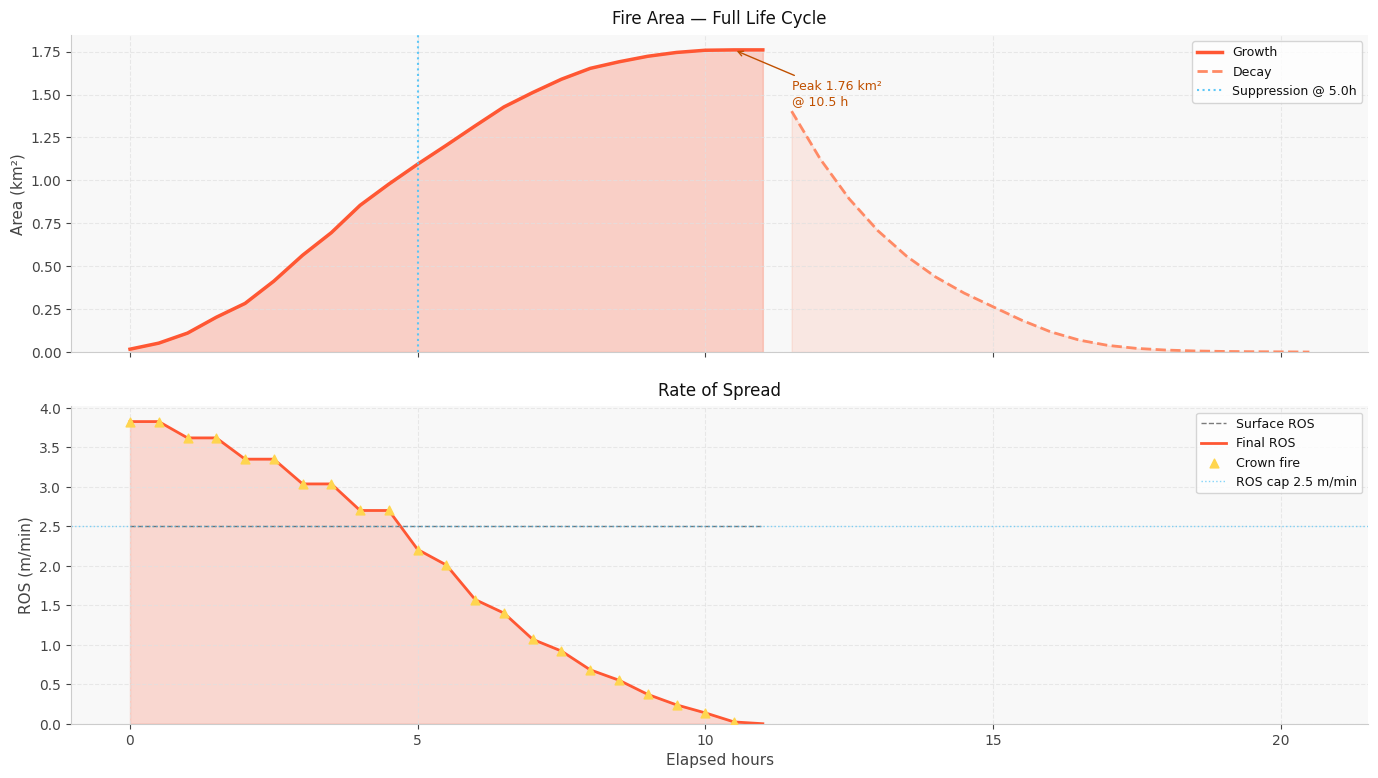

Saved → fig_area_ros.png


In [45]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor(BG)

# Panel 1: Area
ax = axes[0]
ax.set_facecolor(PANEL)
ax.fill_between(sg['elapsed_hours'], sg['area_km2'], alpha=0.25, color=ACCENT)
ax.plot(sg['elapsed_hours'], sg['area_km2'], color=ACCENT, lw=2.5, label='Growth')
if not sd.empty:
    ax.fill_between(sd['elapsed_hours'], sd['area_km2'], alpha=0.15, color=DECAY_C)
    ax.plot(sd['elapsed_hours'], sd['area_km2'], color=DECAY_C, lw=2, ls='--', label='Decay')

pk = sg.loc[sg['area_km2'].idxmax()]
ax.annotate(f"Peak {pk['area_km2']:.2f} km²\n@ {pk['elapsed_hours']:.1f} h",
            xy=(pk['elapsed_hours'], pk['area_km2']),
            xytext=(pk['elapsed_hours']+1, pk['area_km2']*0.82),
            color='#c05000', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#c05000', lw=1))

# suppression onset line
if 'suppression_factor' in sg.columns:
    supp_rows = sg[sg['suppression_factor'] < 1.0]
    if not supp_rows.empty:
        ax.axvline(supp_rows.iloc[0]['elapsed_hours'], color=BLUE, ls=':', lw=1.5,
                   alpha=0.9, label=f"Suppression @ {supp_rows.iloc[0]['elapsed_hours']:.1f}h")

ax.set_ylabel('Area (km²)', fontsize=11)
ax.set_title('Fire Area — Full Life Cycle', fontsize=12, pad=8)
ax.legend(fontsize=9); ax.grid(True)
ax.set_ylim(bottom=0)

# Panel 2: ROS
ax2 = axes[1]
ax2.set_facecolor(PANEL)
ax2.plot(sg['elapsed_hours'], sg['ros_surface_m_min'], color=GREY, lw=1, ls='--',
         alpha=0.7, label='Surface ROS')
ax2.plot(sg['elapsed_hours'], sg['ros_final_m_min'], color=ACCENT, lw=2, label='Final ROS')
ax2.fill_between(sg['elapsed_hours'], sg['ros_final_m_min'], alpha=0.2, color=ACCENT)

if 'crown_fire' in sg.columns:
    crown = sg[sg['crown_fire'] != 'none']
    if not crown.empty:
        ax2.scatter(crown['elapsed_hours'], crown['ros_final_m_min'],
                    color=YELLOW, s=40, zorder=5, label='Crown fire', marker='^')

ax2.axhline(2.5, color=BLUE, ls=':', lw=1, alpha=0.7, label='ROS cap 2.5 m/min')
ax2.set_ylabel('ROS (m/min)', fontsize=11)
ax2.set_xlabel('Elapsed hours', fontsize=11)
ax2.set_title('Rate of Spread', fontsize=12, pad=8)
ax2.legend(fontsize=9); ax2.grid(True)
ax2.set_ylim(bottom=0)

plt.tight_layout(pad=1.5)
plt.savefig(_OUTPUT_DIR / 'fig_area_ros.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved → fig_area_ros.png")


## D — Weather Time-Series (Temperature, Humidity, Wind)

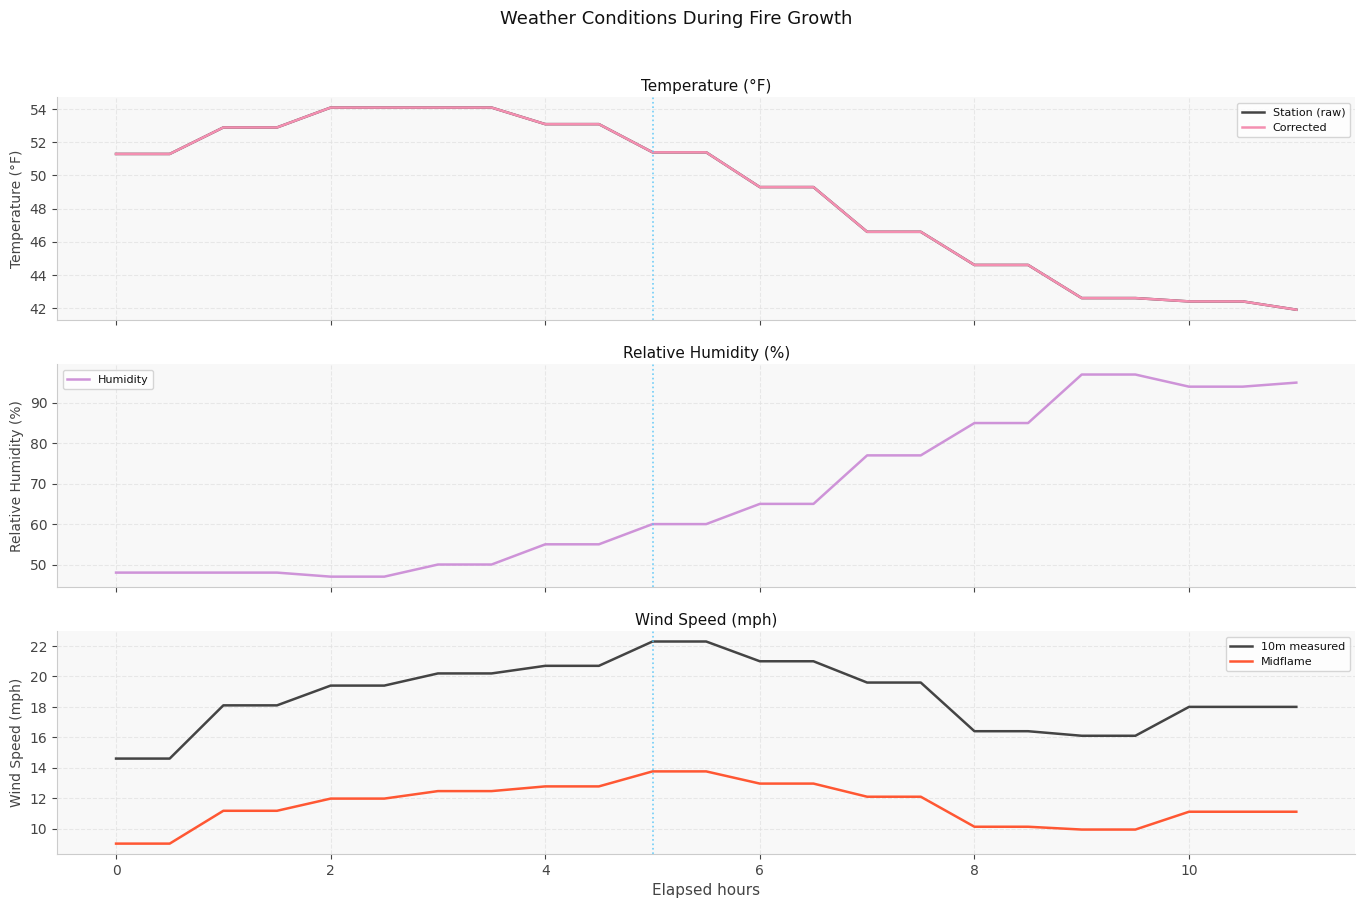

Saved → fig_weather.png


In [30]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Weather Conditions During Fire Growth', fontsize=13, y=1.01)

cols_check = [('temp_f','temp_f_corrected'), ('humidity_pct',), ('wind_speed_10m_mph','wind_midflame_mph')]
titles = ['Temperature (°F)', 'Relative Humidity (%)', 'Wind Speed (mph)']
colors_pairs = [(GREY, '#F48FB1'), (PURPLE,), (GREY, ACCENT)]
labels_pairs = [('Station (raw)', 'Corrected'), ('Humidity',), ('10m measured', 'Midflame')]

for ax, cols, title, colors, labels in zip(axes, cols_check, titles, colors_pairs, labels_pairs):
    ax.set_facecolor(PANEL)
    for col, color, label in zip(cols, colors, labels):
        if col in sg.columns:
            ax.plot(sg['elapsed_hours'], sg[col], color=color, lw=1.8, label=label)
    ax.set_ylabel(title, fontsize=10); ax.set_title(title, fontsize=11, pad=5)
    ax.legend(fontsize=8); ax.grid(True)

axes[-1].set_xlabel('Elapsed hours', fontsize=11)

# Mark suppression onset
for ax in axes:
    if 'suppression_factor' in sg.columns:
        s_rows = sg[sg['suppression_factor'] < 1.0]
        if not s_rows.empty:
            ax.axvline(s_rows.iloc[0]['elapsed_hours'], color=BLUE, ls=':', lw=1.2, alpha=0.8)

plt.tight_layout(pad=1.5)
plt.savefig(_OUTPUT_DIR / 'fig_weather.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_weather.png")


## E — Fuel Moisture & Equilibrium Moisture Content

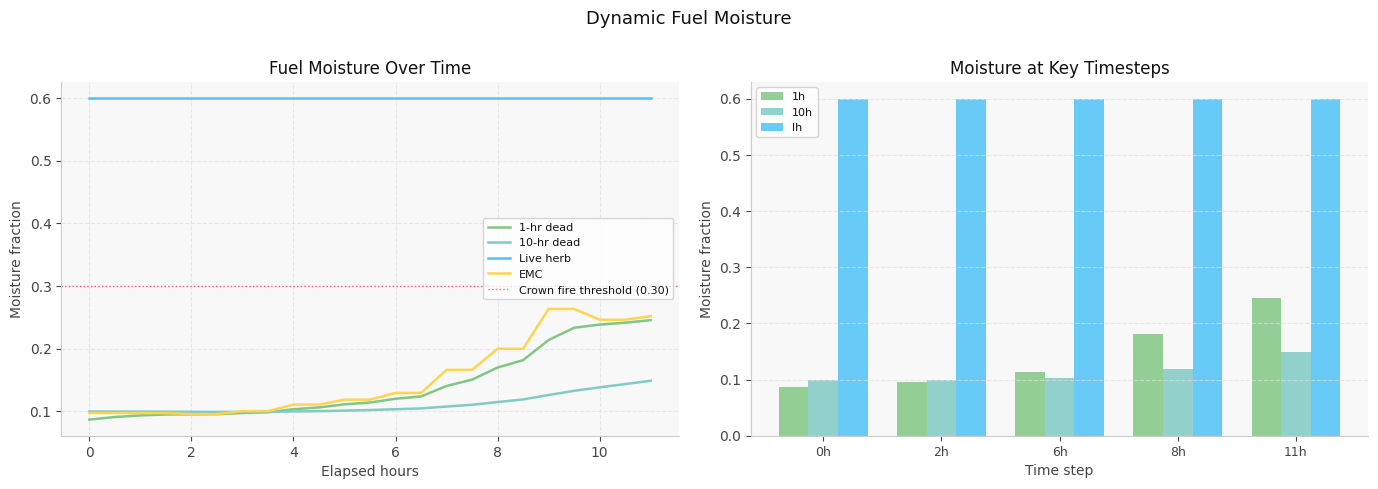

Saved → fig_fuel_moisture.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Dynamic Fuel Moisture', fontsize=13)

ax = axes[0]
ax.set_facecolor(PANEL)
for col, color, label in [
    ('moist_1h_dynamic', GREEN, '1-hr dead'),
    ('moist_10h_dynamic', TEAL, '10-hr dead'),
    ('moist_lh_dynamic', BLUE, 'Live herb'),
    ('emc', YELLOW, 'EMC'),
]:
    if col in sg.columns:
        ax.plot(sg['elapsed_hours'], sg[col], color=color, lw=1.8, label=label)
ax.axhline(0.30, color='red', ls=':', lw=1, alpha=0.6, label='Crown fire threshold (0.30)')
ax.set_xlabel('Elapsed hours'); ax.set_ylabel('Moisture fraction')
ax.set_title('Fuel Moisture Over Time'); ax.legend(fontsize=8); ax.grid(True)


ax2 = axes[1]
ax2.set_facecolor(PANEL)
times = [0, len(sg)//4, len(sg)//2, 3*len(sg)//4, len(sg)-1]
time_labels = [f"{sg.iloc[t]['elapsed_hours']:.0f}h" for t in times if t < len(sg)]
times = [t for t in times if t < len(sg)]
cols_bar = ['moist_1h_dynamic','moist_10h_dynamic','moist_lh_dynamic']
cols_bar = [c for c in cols_bar if c in sg.columns]
bar_colors = [GREEN, TEAL, BLUE]
x = np.arange(len(times)); width = 0.25
for j, (col, color) in enumerate(zip(cols_bar, bar_colors)):
    vals = [float(sg.iloc[t][col]) for t in times]
    ax2.bar(x + j*width, vals, width, color=color, alpha=0.85,
            label=col.replace('_dynamic','').replace('moist_',''))
ax2.set_xticks(x + width); ax2.set_xticklabels(time_labels, fontsize=9)
ax2.set_xlabel('Time step'); ax2.set_ylabel('Moisture fraction')
ax2.set_title('Moisture at Key Timesteps'); ax2.legend(fontsize=8); ax2.grid(True, axis='y')

plt.tight_layout(pad=1.5)
plt.savefig(_OUTPUT_DIR / 'fig_fuel_moisture.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_fuel_moisture.png")


## F — Suppression Factor & Road Access

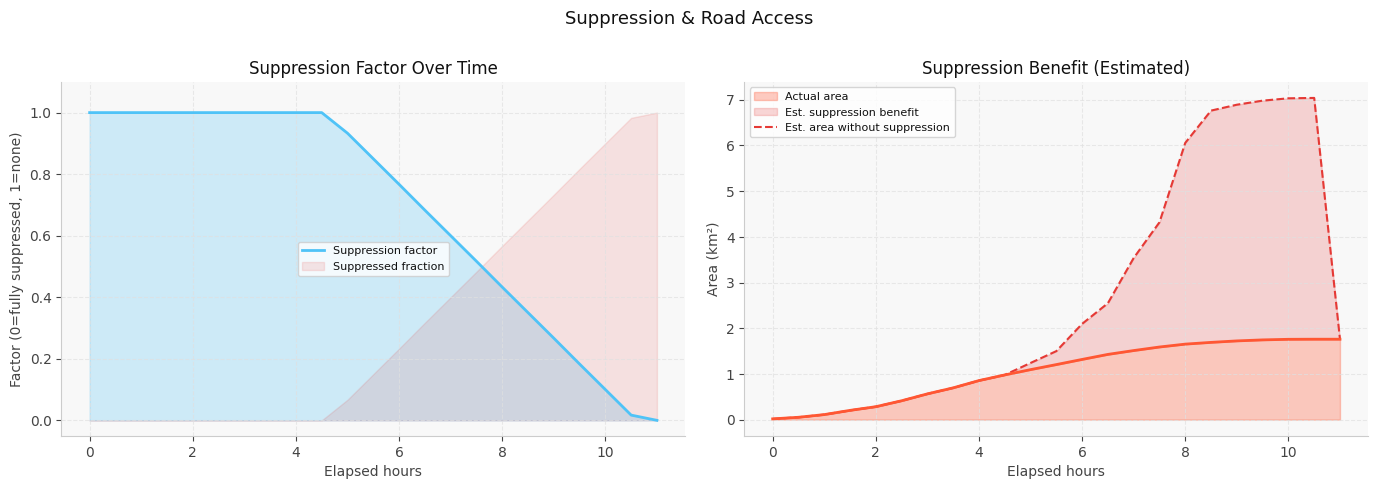

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Suppression & Road Access', fontsize=13)


ax = axes[0]
ax.set_facecolor(PANEL)
if 'suppression_factor' in sg.columns:
    ax.fill_between(sg['elapsed_hours'], sg['suppression_factor'], alpha=0.25, color=BLUE)
    ax.plot(sg['elapsed_hours'], sg['suppression_factor'], color=BLUE, lw=2,
            label='Suppression factor')
    ax.fill_between(sg['elapsed_hours'], 0, 1 - sg['suppression_factor'],
                    alpha=0.12, color=RED, label='Suppressed fraction')
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Elapsed hours'); ax.set_ylabel('Factor (0=fully suppressed, 1=none)')
ax.set_title('Suppression Factor Over Time'); ax.legend(fontsize=8); ax.grid(True)


ax2 = axes[1]
ax2.set_facecolor(PANEL)
ax2.fill_between(sg['elapsed_hours'], sg['area_km2'], alpha=0.3, color=ACCENT, label='Actual area')

if 'ros_surface_m_min' in sg.columns and 'ros_final_m_min' in sg.columns:
    ratio = (sg['ros_surface_m_min'] / sg['ros_final_m_min'].replace(0, np.nan)).fillna(1).clip(1,4)
    est_no_supp = (sg['area_km2'] * ratio).clip(lower=sg['area_km2'])
    ax2.fill_between(sg['elapsed_hours'], est_no_supp, sg['area_km2'],
                     alpha=0.2, color=RED, label='Est. suppression benefit')
    ax2.plot(sg['elapsed_hours'], est_no_supp, color=RED, lw=1.5, ls='--',
             label='Est. area without suppression')
ax2.plot(sg['elapsed_hours'], sg['area_km2'], color=ACCENT, lw=2)
ax2.set_xlabel('Elapsed hours'); ax2.set_ylabel('Area (km²)')
ax2.set_title('Suppression Benefit (Estimated)'); ax2.legend(fontsize=8); ax2.grid(True)

plt.tight_layout(pad=1.5)
plt.savefig(_OUTPUT_DIR / 'fig_suppression.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## G — Structure Ignition Risk

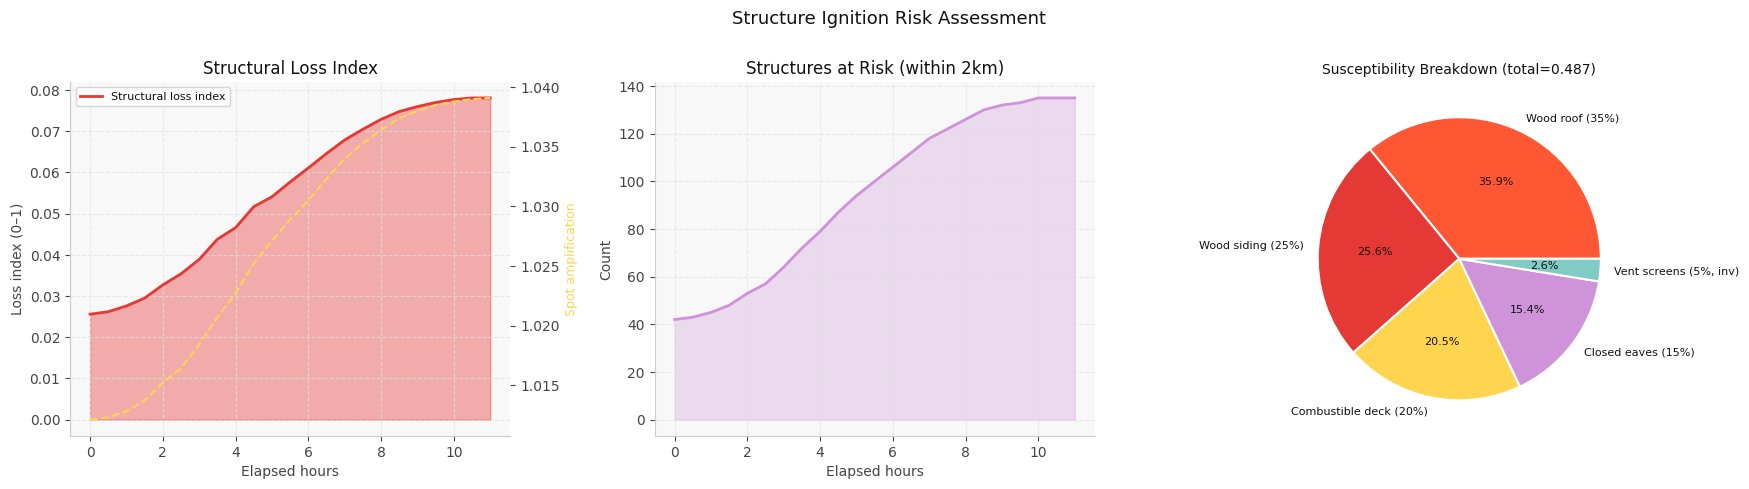

Saved → fig_structure_risk.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Structure Ignition Risk Assessment', fontsize=13)


ax = axes[0]
ax.set_facecolor(PANEL)
if 'structural_loss_index' in sg.columns:
    ax.fill_between(sg['elapsed_hours'], sg['structural_loss_index'], alpha=0.4, color=RED)
    ax.plot(sg['elapsed_hours'], sg['structural_loss_index'], color=RED, lw=2,
            label='Structural loss index')
    if 'spot_amplification' in sg.columns:
        ax2b = ax.twinx(); ax2b.set_facecolor(PANEL)
        ax2b.plot(sg['elapsed_hours'], sg['spot_amplification'],
                  color=YELLOW, lw=1.5, ls='--', label='Spot amplification')
        ax2b.set_ylabel('Spot amplification', fontsize=9, color=YELLOW)
        ax2b.tick_params(colors=GREY)
ax.set_xlabel('Elapsed hours'); ax.set_ylabel('Loss index (0–1)')
ax.set_title('Structural Loss Index'); ax.legend(fontsize=8); ax.grid(True)


ax2 = axes[1]
ax2.set_facecolor(PANEL)
if 'n_structures_at_risk' in sg.columns:
    ax2.fill_between(sg['elapsed_hours'], sg['n_structures_at_risk'], alpha=0.3, color=PURPLE)
    ax2.plot(sg['elapsed_hours'], sg['n_structures_at_risk'], color=PURPLE, lw=2)
ax2.set_xlabel('Elapsed hours'); ax2.set_ylabel('Count')
ax2.set_title('Structures at Risk (within 2km)'); ax2.grid(True)


ax3 = axes[2]
ax3.set_facecolor(PANEL)
if not sg.empty and 'ignition_susceptibility' in sg.columns:
    row0 = sg.iloc[0]
    factors = {}
    for col, label, weight in [
        ('frac_wood_roof', 'Wood roof (35%)', 0.35),
        ('frac_wood_siding', 'Wood siding (25%)', 0.25),
        ('frac_combustable_deck', 'Combustible deck (20%)', 0.20),
        ('frac_closed_eaves', 'Closed eaves (15%)', 0.15),
    ]:
        val = float(out_df[col].iloc[0]) if col in out_df.columns else 0.5
        factors[label] = val * weight
    factors['Vent screens (5%, inv)'] = (1 - float(out_df['avg_vent_screens_in'].iloc[0])
                                           if 'avg_vent_screens_in' in out_df.columns else 0.25) * 0.05
    colors_pie = [ACCENT, RED, YELLOW, PURPLE, TEAL]
    wedges, texts, autotexts = ax3.pie(
        list(factors.values()), labels=list(factors.keys()),
        colors=colors_pie[:len(factors)], autopct='%1.1f%%',
        textprops={'color':'#111111','fontsize':8},
        wedgeprops={'edgecolor': BG, 'linewidth': 1.5})
    for at in autotexts: at.set_fontsize(8)
    total_susc = sum(factors.values())
    ax3.set_title(f'Susceptibility Breakdown (total={total_susc:.3f})', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(_OUTPUT_DIR / 'fig_structure_risk.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_structure_risk.png")


## H — Crown Fire, Burning Index & Energy Release

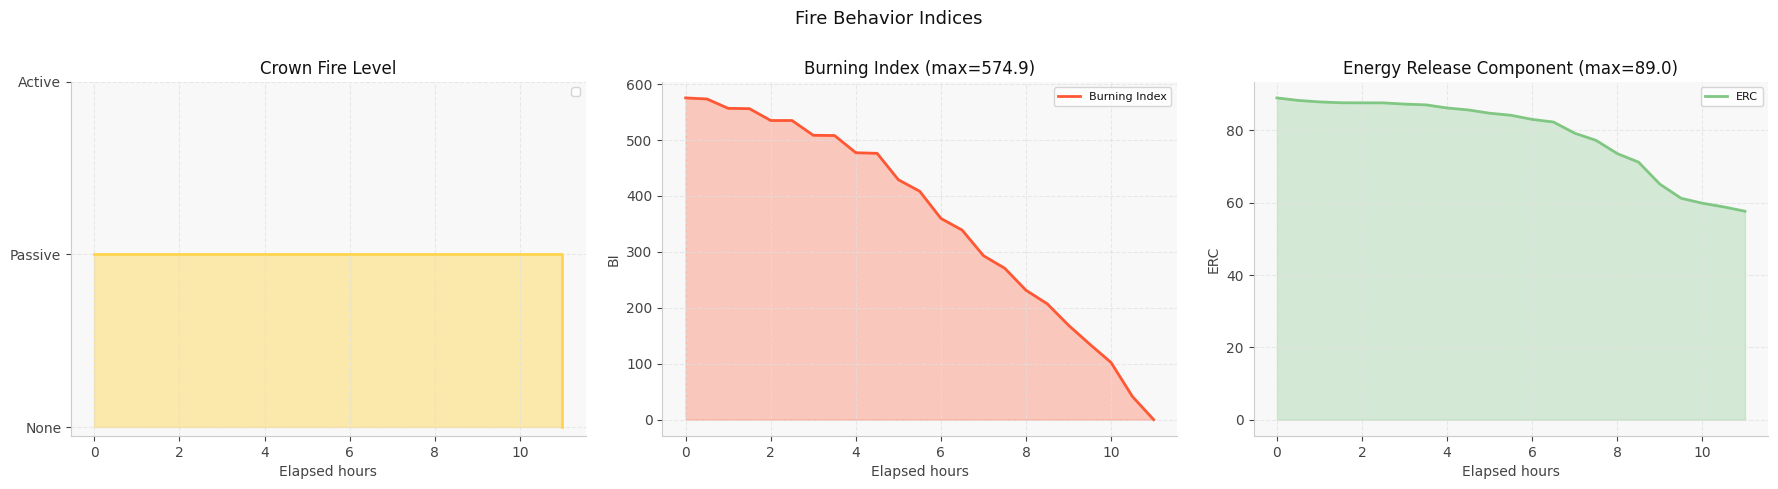

Saved → fig_fire_behavior.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Fire Behavior Indices', fontsize=13)


ax = axes[0]
ax.set_facecolor(PANEL)
cm = {'none': 0, 'passive': 1, 'active': 2}
if 'crown_fire' in sg.columns:
    cv = sg['crown_fire'].map(cm).fillna(0)
    ax.fill_between(sg['elapsed_hours'], cv, alpha=0.45, color=YELLOW, step='post')
    ax.step(sg['elapsed_hours'], cv, color=YELLOW, lw=2, where='post')
    # spot fires
    if 'new_spot_fires' in sg.columns:
        spots = sg[sg['new_spot_fires'] > 0]
        if not spots.empty:
            ax.scatter(spots['elapsed_hours'], [0.5]*len(spots), color=ACCENT,
                       s=80, zorder=5, marker='*', label='Spot fire')
ax.set_yticks([0,1,2]); ax.set_yticklabels(['None','Passive','Active'])
ax.set_xlabel('Elapsed hours'); ax.set_title('Crown Fire Level')
ax.legend(fontsize=8); ax.grid(True)


ax2 = axes[1]
ax2.set_facecolor(PANEL)
if 'burning_index' in sg.columns:
    ax2.fill_between(sg['elapsed_hours'], sg['burning_index'], alpha=0.3, color=ACCENT)
    ax2.plot(sg['elapsed_hours'], sg['burning_index'], color=ACCENT, lw=2, label='Burning Index')
ax2.set_xlabel('Elapsed hours'); ax2.set_ylabel('BI')
ax2.set_title(f"Burning Index (max={sg['burning_index'].max():.1f})")
ax2.legend(fontsize=8); ax2.grid(True)


ax3 = axes[2]
ax3.set_facecolor(PANEL)
if 'erc' in sg.columns:
    ax3.fill_between(sg['elapsed_hours'], sg['erc'], alpha=0.3, color=GREEN)
    ax3.plot(sg['elapsed_hours'], sg['erc'], color=GREEN, lw=2, label='ERC')
ax3.set_xlabel('Elapsed hours'); ax3.set_ylabel('ERC')
ax3.set_title(f"Energy Release Component (max={sg['erc'].max():.1f})")
ax3.legend(fontsize=8); ax3.grid(True)

plt.tight_layout(pad=1.5)
plt.savefig(_OUTPUT_DIR / 'fig_fire_behavior.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_fire_behavior.png")


## I — Decay Phase Analysis

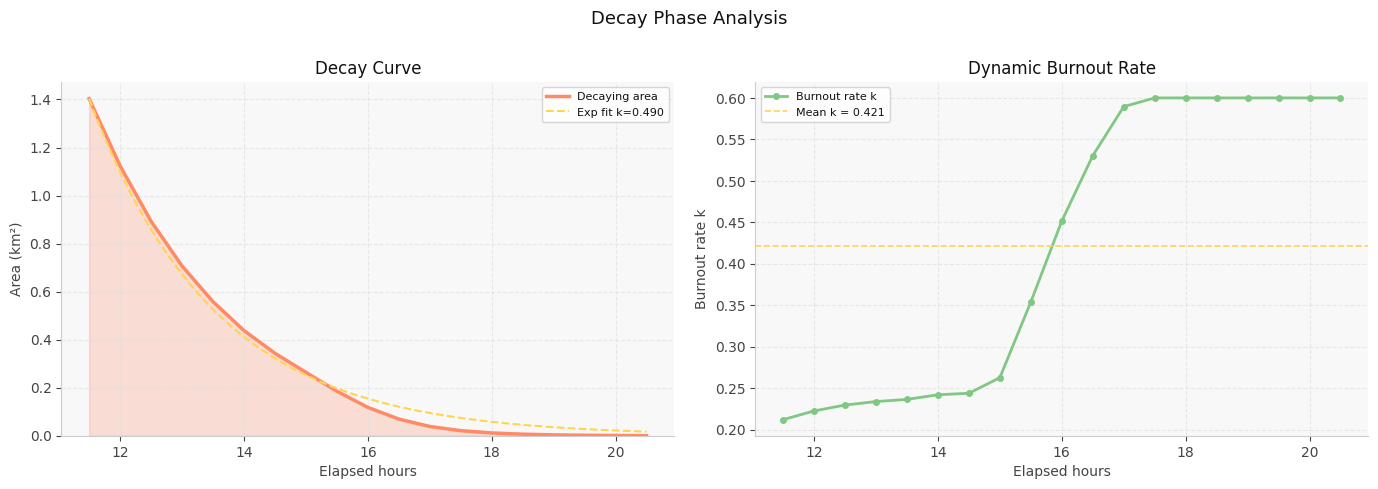

Saved → fig_decay.png


In [35]:
if sd.empty:
    print("No decay data available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle('Decay Phase Analysis', fontsize=13)

    ax = axes[0]
    ax.set_facecolor(PANEL)
    ax.fill_between(sd['elapsed_hours'], sd['area_km2'], alpha=0.25, color=DECAY_C)
    ax.plot(sd['elapsed_hours'], sd['area_km2'], color=DECAY_C, lw=2.5, label='Decaying area')
    # Fit exponential
    try:
        from scipy.optimize import curve_fit
        t0 = sd['elapsed_hours'].iloc[0]
        t  = sd['elapsed_hours'].values - t0
        a  = sd['area_km2'].values
        popt, _ = curve_fit(lambda t, k: a[0]*np.exp(-k*t), t, a, p0=[0.2], maxfev=2000)
        t_fit = np.linspace(0, t[-1], 200)
        ax.plot(t_fit + t0, a[0]*np.exp(-popt[0]*t_fit),
                color=YELLOW, lw=1.5, ls='--', label=f'Exp fit k={popt[0]:.3f}')
    except Exception: pass
    ax.set_xlabel('Elapsed hours'); ax.set_ylabel('Area (km²)')
    ax.set_title('Decay Curve'); ax.legend(fontsize=8); ax.grid(True)
    ax.set_ylim(bottom=0)

    ax2 = axes[1]
    ax2.set_facecolor(PANEL)
    if 'burnout_k' in sd.columns:
        ax2.plot(sd['elapsed_hours'], sd['burnout_k'], color=GREEN, lw=2, marker='o',
                 markersize=4, label='Burnout rate k')
        ax2.axhline(sd['burnout_k'].mean(), color=YELLOW, ls='--', lw=1.2,
                    label=f"Mean k = {sd['burnout_k'].mean():.3f}")
    ax2.set_xlabel('Elapsed hours'); ax2.set_ylabel('Burnout rate k')
    ax2.set_title('Dynamic Burnout Rate'); ax2.legend(fontsize=8); ax2.grid(True)

    plt.tight_layout(pad=1.5)
    plt.savefig(_OUTPUT_DIR / 'fig_decay.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved → fig_decay.png")


## J — Perimeter Growth Table (every 6 steps)

In [36]:
from IPython.display import display, HTML

step = max(1, len(sg)//12)
rows_g = sg.iloc[::step][['elapsed_hours','area_km2','perimeter_km',
                           'ros_final_m_min','crown_fire','suppression_factor',
                           'structural_loss_index','n_structures_at_risk',
                           'moist_1h_dynamic','wind_midflame_mph']].copy()
rows_g.columns = ['Elapsed h','Area km²','Perim km','ROS m/min',
                  'Crown','Supp factor','Struct loss','N at risk',
                  'M1h','Wind mf mph']
for col in ['Area km²','Perim km','ROS m/min','Supp factor','Struct loss','M1h','Wind mf mph']:
    rows_g[col] = pd.to_numeric(rows_g[col], errors='coerce').round(4)
rows_g['Elapsed h'] = rows_g['Elapsed h'].round(1)

html = rows_g.to_html(index=False, classes='stat-table', border=0)
style = """<style>
  .stat-table {border-collapse:collapse; width:100%; font-family:monospace; font-size:12px; background:white;}
  .stat-table th {background:#e8f0fe; color:#1a3a6b; padding:6px 10px; text-align:left;}
  .stat-table td {padding:4px 10px; border-bottom:1px solid #e0e0e0; color:#222;}
  .stat-table tr:hover td {background:#f0f4ff;}
</style>"""
display(HTML(style + html))


Elapsed h,Area km²,Perim km,ROS m/min,Crown,Supp factor,Struct loss,N at risk,M1h,Wind mf mph
0.0,0.0166,0.5748,3.8258,passive,1.000,0.0256,42,0.0869,9.007
0.5,0.0518,1.0559,3.8258,passive,1.000,0.0262,43,0.0911,9.007
1.0,0.1103,1.5525,3.6192,passive,1.000,0.0276,45,0.0936,11.166
1.5,0.2026,2.2816,3.6192,passive,1.000,0.0295,48,0.0951,11.166
2.0,0.2832,2.7021,3.3500,passive,1.000,0.0327,53,0.0953,11.968
2.5,0.4130,4.2079,3.3500,passive,1.000,0.0354,57,0.0955,11.968
3.0,0.5639,5.6500,3.0365,passive,1.000,0.0389,64,0.0975,12.461
3.5,0.6956,6.2920,3.0365,passive,1.000,0.0438,72,0.0987,12.461
4.0,0.8549,7.2382,2.7000,passive,1.000,0.0466,79,0.1035,12.770
4.5,0.9785,7.7664,2.7000,passive,1.000,0.0517,87,0.1064,12.770


## K — Fire Perimeter Evolution Map

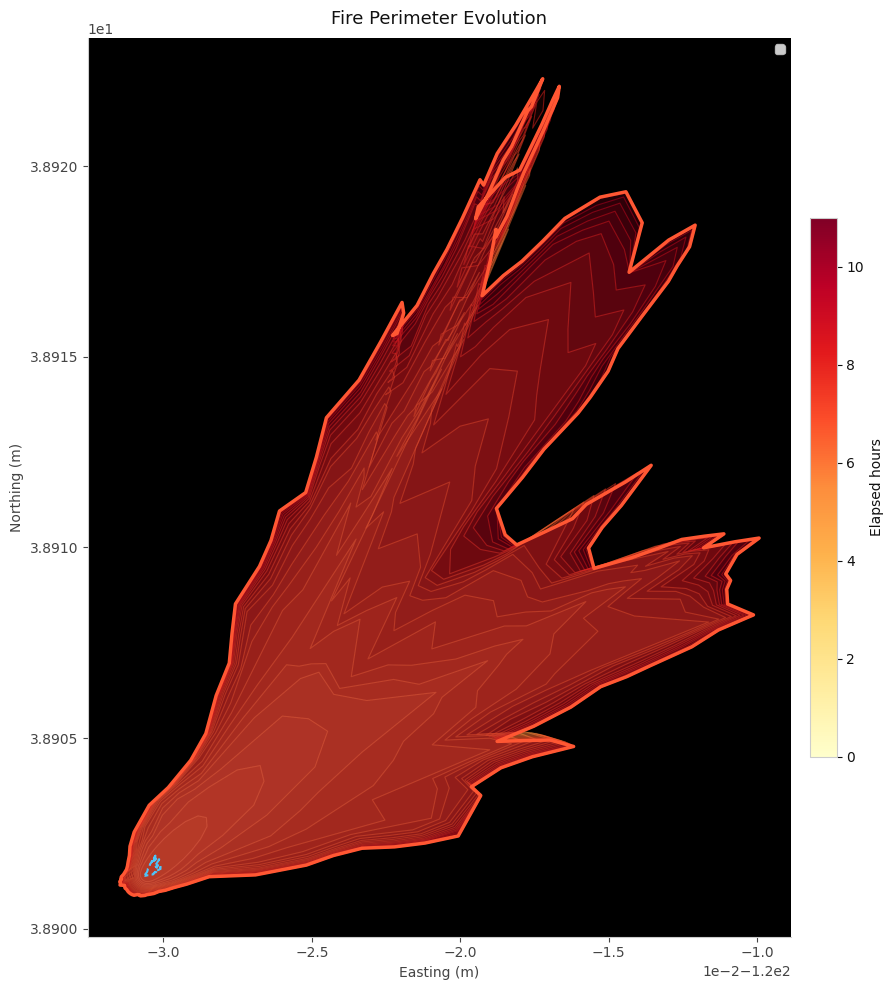

Saved → fig_perimeter_map.png


In [37]:
import geopandas as gpd
from shapely import wkt as swkt
import shapely.ops as so
from pyproj import Transformer

geojson_path = _OUTPUT_DIR / 'spread_perimeters_projected.geojson'
if not geojson_path.exists():
    print("GeoJSON not found — run model first")
else:
    gdf = gpd.read_file(geojson_path)
    gdf_g = gdf[gdf['phase'] == 'growth'].copy()
    gdf_d = gdf[gdf['phase'].isin(['decay','extinguished'])].copy()

    fig, ax = plt.subplots(figsize=(10, 10))
    fig.patch.set_facecolor(BG); ax.set_facecolor("black")

    n = max(len(gdf_g), 1)
    cmap = plt.cm.YlOrRd

    for i, (_, row) in enumerate(gdf_g.iterrows()):
        color = cmap(0.1 + 0.9 * i / n)
        try:
            gpd.GeoDataFrame([row], geometry='geometry', crs=gdf.crs).plot(
                ax=ax, facecolor=(*color[:3], 0.08), edgecolor=(*color[:3], 0.5),
                linewidth=0.8)
        except: pass

    # Final perimeter thick
    if not gdf_g.empty:
        gpd.GeoDataFrame([gdf_g.iloc[-1]], geometry='geometry', crs=gdf.crs).plot(
            ax=ax, facecolor='none', edgecolor=ACCENT, linewidth=2.5, label='Peak perimeter')
    if not gdf_d.empty:
        gpd.GeoDataFrame([gdf_d.iloc[-1]], geometry='geometry', crs=gdf.crs).plot(
            ax=ax, facecolor='none', edgecolor=BLUE, linewidth=1.5, ls='--', label='Final decay')

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, gdf_g['elapsed_hours'].max()
                                                               if not gdf_g.empty else 1))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('Elapsed hours', color='#111111')
    cb.ax.yaxis.set_tick_params(color='#111111')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#111111')

    ax.set_title('Fire Perimeter Evolution', fontsize=13, pad=10)
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

    plt.tight_layout()
    plt.savefig(_OUTPUT_DIR / 'fig_perimeter_map.png', dpi=150,
                bbox_inches='tight', facecolor='black')
    plt.show()
    print("Saved → fig_perimeter_map.png")


## L — Correlation Matrix: Fire Behavior Variables

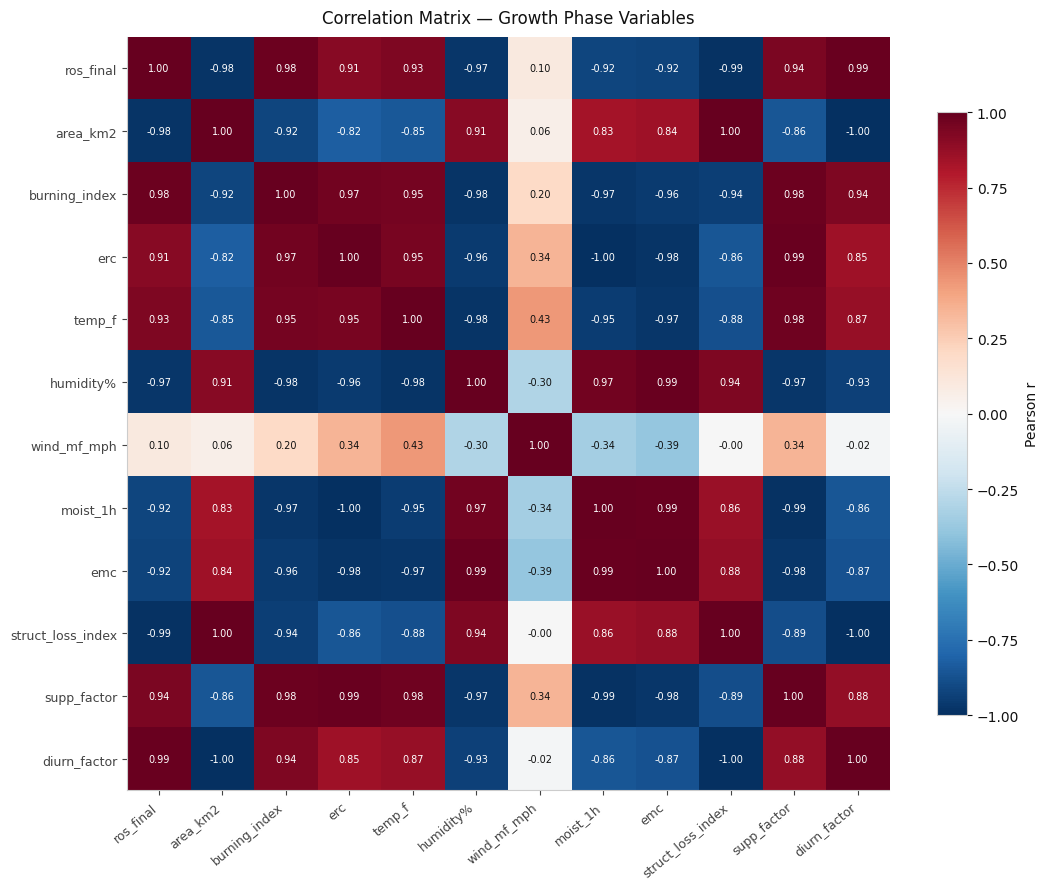

Saved → fig_correlation.png


In [38]:
corr_cols = [c for c in ['ros_final_m_min','area_km2','burning_index','erc',
                          'temp_f','humidity_pct','wind_midflame_mph',
                          'moist_1h_dynamic','emc','structural_loss_index',
                          'suppression_factor','diurnal_factor']
             if c in sg.columns]
corr = sg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)

im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

short = [c.replace('_m_min','').replace('_dynamic','').replace('_pct','%')
           .replace('midflame_','mf_').replace('structural_','struct_')
           .replace('suppression_','supp_').replace('diurnal_','diurn_')
         for c in corr_cols]
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(short, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(short, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha='center', va='center',
                fontsize=7, color='white' if abs(v) > 0.6 else '#111111')

cb = plt.colorbar(im, ax=ax, shrink=0.8)
cb.set_label('Pearson r', color='#111111')
cb.ax.yaxis.set_tick_params(color='#111111')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#111111')

ax.set_title('Correlation Matrix — Growth Phase Variables', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(_OUTPUT_DIR / 'fig_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_correlation.png")


## M — Export Full Statistics to CSV & Summary Report

In [39]:
stat_records = {
    "metric": [], "value": [], "unit": [], "phase": []
}

def add(metric, value, unit, phase):
    stat_records["metric"].append(metric)
    stat_records["value"].append(value)
    stat_records["unit"].append(unit)
    stat_records["phase"].append(phase)

# Growth
add("peak_area",              sg["area_km2"].max(),              "km²",    "growth")
add("time_of_peak_area",      sg.loc[sg["area_km2"].idxmax(),"elapsed_hours"], "h", "growth")
add("growth_duration",        sg["elapsed_hours"].max(),         "h",      "growth")
add("growth_steps",           len(sg),                           "steps",  "growth")
add("max_ros_final",          sg["ros_final_m_min"].max(),       "m/min",  "growth")
add("mean_ros_final",         sg["ros_final_m_min"].mean(),      "m/min",  "growth")
add("max_ros_surface",        sg["ros_surface_m_min"].max(),     "m/min",  "growth")
if "burning_index" in sg: add("max_burning_index",  sg["burning_index"].max(),    "—",  "growth")
if "erc" in sg:           add("max_erc",            sg["erc"].max(),              "—",  "growth")
if "crown_fire" in sg:    add("crown_fire_steps",   (sg["crown_fire"]!="none").sum(), "steps", "growth")
if "new_spot_fires" in sg: add("total_spot_fires",  sg["new_spot_fires"].sum(),   "count","growth")
if "temp_f" in sg:
    add("mean_temp_f",        sg["temp_f"].mean(),               "°F",     "growth")
    add("min_temp_f",         sg["temp_f"].min(),                "°F",     "growth")
    add("max_temp_f",         sg["temp_f"].max(),                "°F",     "growth")
if "humidity_pct" in sg:  add("mean_humidity",      sg["humidity_pct"].mean(),    "%",  "growth")
if "wind_midflame_mph" in sg: add("mean_midflame_wind", sg["wind_midflame_mph"].mean(), "mph","growth")
if "moist_1h_dynamic" in sg:
    add("initial_moist_1h",   sg["moist_1h_dynamic"].iloc[0],   "frac",   "growth")
    add("final_moist_1h",     sg["moist_1h_dynamic"].iloc[-1],  "frac",   "growth")
if "structural_loss_index" in sg:
    add("max_struct_loss_idx",sg["structural_loss_index"].max(), "0-1",    "growth")
    add("max_n_at_risk",      sg["n_structures_at_risk"].max(),  "count",  "growth")
if "road_density_km_per_km2" in sg:
    add("road_density",       sg["road_density_km_per_km2"].mean(),"km/km²","growth")
if "nearest_road_m" in sg:
    add("nearest_road",       sg["nearest_road_m"].iloc[0],     "m",      "growth")

# Decay
if not sd.empty:
    add("decay_steps",        len(sd),                           "steps",  "decay")
    add("extinction_time",    sd["elapsed_hours"].max(),         "h",      "decay")
    add("full_duration",      out_df["elapsed_hours"].max(),     "h",      "both")
    if "burnout_k" in sd:
        add("mean_burnout_k", sd["burnout_k"].mean(),            "—",      "decay")
        add("max_burnout_k",  sd["burnout_k"].max(),             "—",      "decay")

stats_df = pd.DataFrame(stat_records)
stats_df.to_csv(_OUTPUT_DIR / "fire_statistics.csv", index=False)
print(f"Saved → fire_statistics.csv  ({len(stats_df)} metrics)")
print()
print(stats_df.to_string(index=False))


Saved → fire_statistics.csv  (27 metrics)

             metric      value   unit  phase
          peak_area   1.760180    km² growth
  time_of_peak_area  10.500000      h growth
    growth_duration  11.000000      h growth
       growth_steps  23.000000  steps growth
      max_ros_final   3.825833  m/min growth
     mean_ros_final   1.923553  m/min growth
    max_ros_surface   2.500000  m/min growth
  max_burning_index 574.930000      — growth
            max_erc  88.990000      — growth
   crown_fire_steps  22.000000  steps growth
   total_spot_fires   0.000000  count growth
        mean_temp_f  48.986957     °F growth
         min_temp_f  41.900000     °F growth
         max_temp_f  54.100000     °F growth
      mean_humidity  67.260870      % growth
 mean_midflame_wind  11.554783    mph growth
   initial_moist_1h   0.086900   frac growth
     final_moist_1h   0.245600   frac growth
max_struct_loss_idx   0.078100    0-1 growth
      max_n_at_risk 135.000000  count growth
       road_